# Set up conda
```
curl -O https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh
bash ./Miniconda3-latest-Linux-x86_64.sh

source ~/.bashrc

conda config --add channels bioconda & /
conda config --add channels conda-forge & /
conda config --set channel_priority strict & /
conda create --name bio-prak & /
conda activate bio-prak
conda instapp python=3.13 -y
conda install viennarna=2.7.2 bedtools jupyterlab scipy matplotlib pandas biopython samtools fasta -y
```

# Initial Files:
- GCF_000001405.40_GRCh38.p14_genomic.fna.gz  
    - https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_genomic.fna.gz
    - Full FASTA Human Genome Sequence
- GCF_000001405.40_GRCh38.p14_genomic.gtf.gz
    - https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/001/405/GCF_000001405.40_GRCh38.p14/GCF_000001405.40_GRCh38.p14_genomic.gtf.gz
    - GTF Genome Region Annotations for all Chromosomes   
- hg38.m6A.gz
    - http://bioinformaticsscience.cn/rmbase/download.php
    - Group: Mammal
    - Genome: Homo Sapiens
    - Assembly: hg38
    - Mod Type: m6A
    - Bed File with m6A Modification annotations for all Chromosomes
    - `tar xpfvz data/original/hg38.m6A.tar.gz -O | gzip -c > data/original/hg38.m6A.gz`

All saved under /data/original

# Renamed Files:
- GCF_000001405.40_GRCh38.p14_genomic.fna.gz -> genome.fna.gz
- GCF_000001405.40_GRCh38.p14_genomic.gtf.gz -> annotated.gtf.gz
- hg38.m6A.gz -> modifications.bed.gz

# Single Chromosome Files:
- Filtered with:
    ```
    zcat modifications.bed.gz | grep chr8 | gzip -c > modifications.bed.chr8.gz
    zcat annotated.gtf.gz | grep NC_000008.11 | gzip -c > annotated_NC_000008.11.gtf.gz
    zcat genome.fna.gz | sed -n '/NC_000008/,/NC_/p' | head -n -1 | gzip -c > genome_NC_000008.11.fna.gz
    ```

In [1]:
import os
from src.files.files import get_files

files = get_files()
original_files = files.get_original_files()
filtered_files = files.get_filtered_files()

with original_files.get_genome_file().open_or_recompute() as fullFasta:
    with filtered_files.get_genome_file().open_or_recompute() as filteredFasta:
        fullFasta.seek(0, os.SEEK_END)
        filteredFasta.seek(0, os.SEEK_END)
        
        print("Fasta filtered from size:", fullFasta.tell(), "to size", filteredFasta.tell())

with original_files.get_annotations_file().open_or_recompute() as fullGtf:
    with filtered_files.get_annotations_file().open_or_recompute() as filteredGtf:
        fullLines = sum(1 for _ in fullGtf)
        filteredLines = sum(1 for _ in filteredGtf)

        print("Annotations filtered from", fullLines, "lines to", filteredLines, "lines")

with original_files.get_modifications_file().open_or_recompute() as fullBed:
    with filtered_files.get_modifications_file().open_or_recompute() as filteredBed:
        fullLines = sum(1 for _ in fullBed)
        filteredLines = sum(1 for _ in filteredBed)

        print("Modifications filtered from", fullLines, "lines to", filteredLines, "lines")

Fasta filtered from size: 3339739109 to size 146952938
Annotations filtered from 4727823 lines to 165373 lines
Modifications filtered from 882385 lines to 28408 lines


# Correct Chromosome Names:
```
zcat annotated_NC_000008.11.gtf.gz | sed 's/NC_000008.11/chr8/g' | gzip -c > annotated_chr8.gtf.gz
zcat genome_NC_000008.11.fna.gz | sed 's/NC_000008.11/chr8/g' | gzip -c > genome_chr8.fna.gz
```

# Bed12 Files:
```
mkdir software
cd software
git clone https://github.com/stephenfloor/extract-transcript-regions.git
```

```
mkdir data/hg38
python software/extract-transcript-regions/extract_transcript_regions.py --gtf -i data/annotated.gtf.gz -o data/hg38/hg38
```

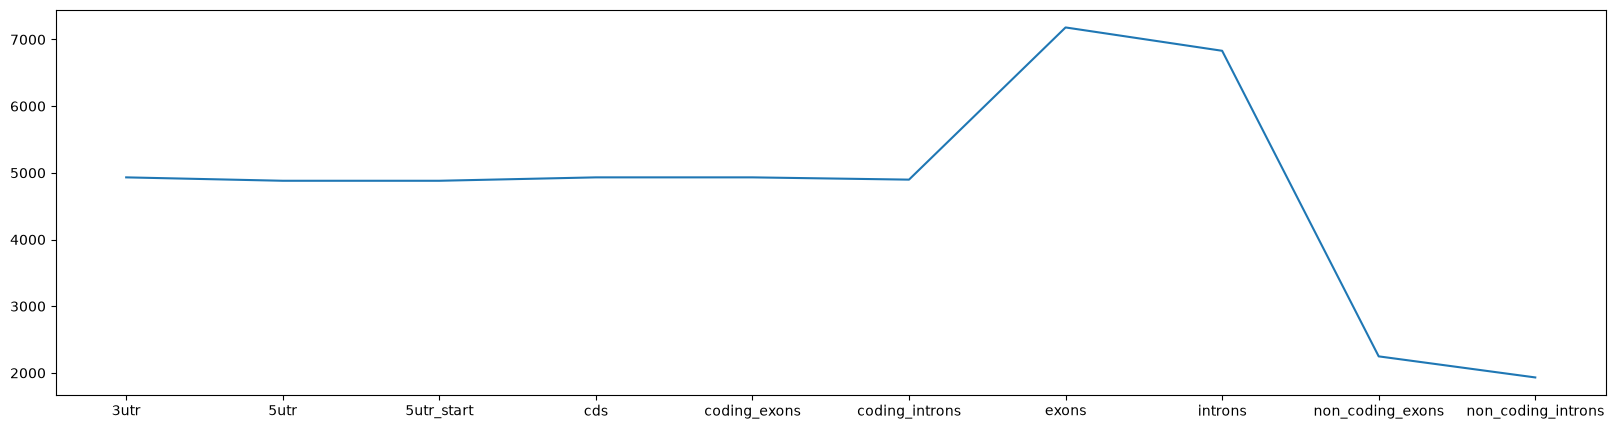

In [2]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

# Bgzip Fasta for getfasta
```
zcat data/genome_chr8.fna.gz | bgzip -c > data/genome_chr8.fna.bgz
```

# GetFasta
```
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_3utr.bed -name | gzip -c > data/hg38/fasta/hg38_3utr.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_5utr.bed -name | gzip -c > data/hg38/fasta/hg38_5utr.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_5utr_start.bed -name | gzip -c > data/hg38/fasta/hg38_5utr_start.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_cds.bed -name | gzip -c > data/hg38/fasta/hg38_cds.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_codingexons.bed -name | gzip -c > data/hg38/fasta/hg38_codingexons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_codingintrons.bed -name | gzip -c > data/hg38/fasta/hg38_codingintrons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_exons.bed -name | gzip -c > data/hg38/fasta/hg38_exons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_introns.bed -name | gzip -c > data/hg38/fasta/hg38_introns.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_noncodingexons.bed -name | gzip -c > data/hg38/fasta/hg38_noncodingexons.fna.gz
bedtools getfasta -s -split -fi data/genome_chr8.fna.bgz -bed data/hg38/hg38_noncodingintrons.bed -name | gzip -c > data/hg38/fasta/hg38_noncodingintrons.fna.gz
```

# Intersects
```
intersectBed -a data/hg38/hg38_3utr.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_3utr_intersect.bed.gz
intersectBed -a data/hg38/hg38_5utr.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_5utr_intersect.bed.gz
intersectBed -a data/hg38/hg38_5utr_start.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_5utr_start_intersect.bed.gz
intersectBed -a data/hg38/hg38_cds.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_cds_intersect.bed.gz
intersectBed -a data/hg38/hg38_codingexons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_codingexons_intersect.bed.gz
intersectBed -a data/hg38/hg38_codingintrons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_codingintrons_intersect.bed.gz
intersectBed -a data/hg38/hg38_exons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_exons_intersect.bed.gz
intersectBed -a data/hg38/hg38_introns.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_introns_intersect.bed.gz
intersectBed -a data/hg38/hg38_noncodingexons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_noncodingexons_intersect.bed.gz
intersectBed -a data/hg38/hg38_noncodingintrons.bed -b data/modifications_chr8.bed.gz -s -split | gzip -c > data/hg38/intersect/hg38_noncodingintrons_intersect.bed.gz
```

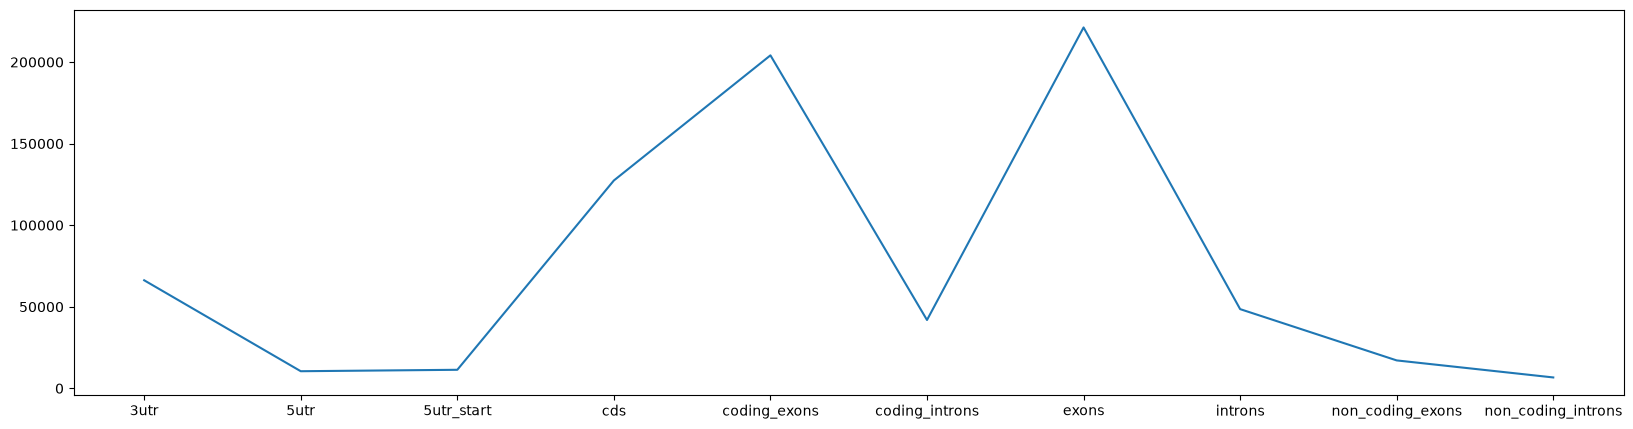

In [4]:
import matplotlib.pyplot as plt
from src.files.files import get_files

line_counts = {}

for key, file in get_files().get_assembled_region_intersects_files().get_files_dict().items():
    line_counts[key] = sum(1 for _ in file.open_or_recompute())

fig, axs = plt.subplots(figsize=(20, 5))
axs.plot(line_counts.keys(), line_counts.values())
plt.show()

# Make local intersects:

# Assemble Modifications



# Sanity Check
Testen, ob alle m6A modification positionen auch A sind

In [1]:
import gzip
import re
import csv
from src.util import load_region_modifications
from src.files.files import get_files

def sanity_check(fastaFile, regions):
    with fastaFile.open_or_recompute() as fastaFile:
        is_in_region = False
        has_region_modifications = False
        current_region_name = None
        current_region_modifications = None
        
        for line in fastaFile:
            if re.search(">", line):
                first_colon = line.find(":")
                
                is_in_region = True
                current_region_name = line[1:first_colon]
                current_region_modifications = []
                has_region_modifications = False
                if current_region_name in regions:
                    current_region_modifications = regions[current_region_name].modifications
                    if len(current_region_modifications):
                        has_region_modifications = True
            else:
                if not is_in_region:
                    continue
                if not has_region_modifications:
                    continue
                line_length = len(line)

                for modification in current_region_modifications:
                    if modification > line_length:
                        break

                    char = line[modification]

                    if char != "A" and char != "a":
                        print("Non A m6A!")

                current_region_modifications = filter(lambda modification: modification > line_length, current_region_modifications)
                current_region_modifications = [x - line_length for x in current_region_modifications]
                if len(current_region_modifications) == 0:
                    has_region_modifications = False

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    print("Checking", key)
    regions = load_region_modifications(file)

    sanity_check(get_files().get_assembled_region_fasta_files().get_files_dict()[key], regions)

print("Done")

Checking 3utr
Checking 5utr
Checking 5utr_start
Checking cds
Checking coding_exons
Checking coding_introns
Checking exons
Checking introns
Checking non_coding_exons
Checking non_coding_introns
Done


Calculating 3utr
Computing Intersects for data/regions/region_3utr.bed into data/regions_intersect/region_3utr_intersect.bed.gz
Computing Intersects for data/regions/region_3utr.bed into data/regions_intersect/region_3utr_intersect.bed.gz done
Converting intersects in data/regions_intersect/region_3utr_intersect.bed.gz into local intersects in data/regions_intersect_local/region_3utr_intersect_local.gz
Converting intersects in data/regions_intersect/region_3utr_intersect.bed.gz into local intersects in data/regions_intersect_local/region_3utr_intersect_local.gz done
Assembling local Intersects for data/regions_intersect_local/region_3utr_intersect_local.gz into data/regions_intersect_local_assembled/region_3utr_intersect_local_assembled.gz
Assembling local Intersects for data/regions_intersect_local/region_3utr_intersect_local.gz into data/regions_intersect_local_assembled/region_3utr_intersect_local_assembled.gz done
Calculating 5utr
Computing Intersects for data/regions/region_5utr.b

/tmp/ipykernel_22034/1413503998.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


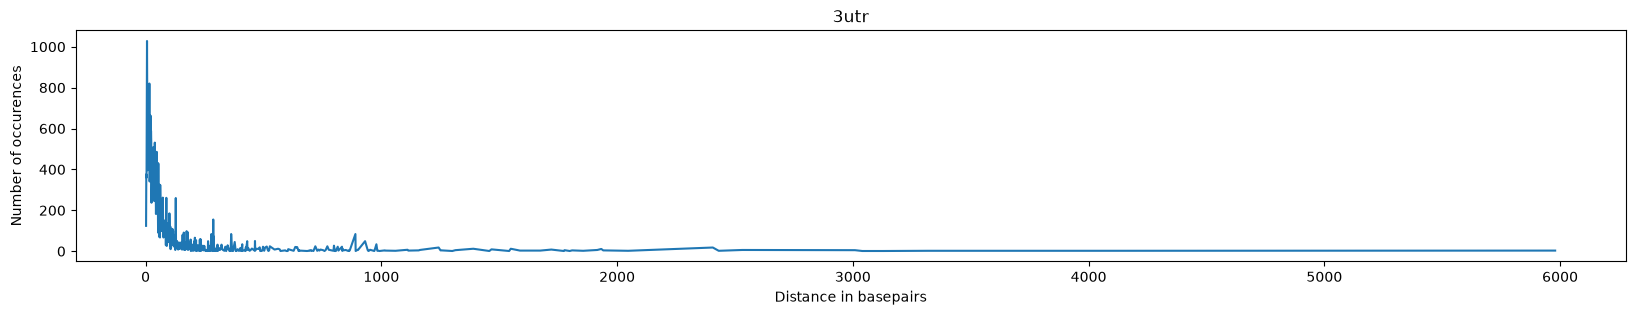

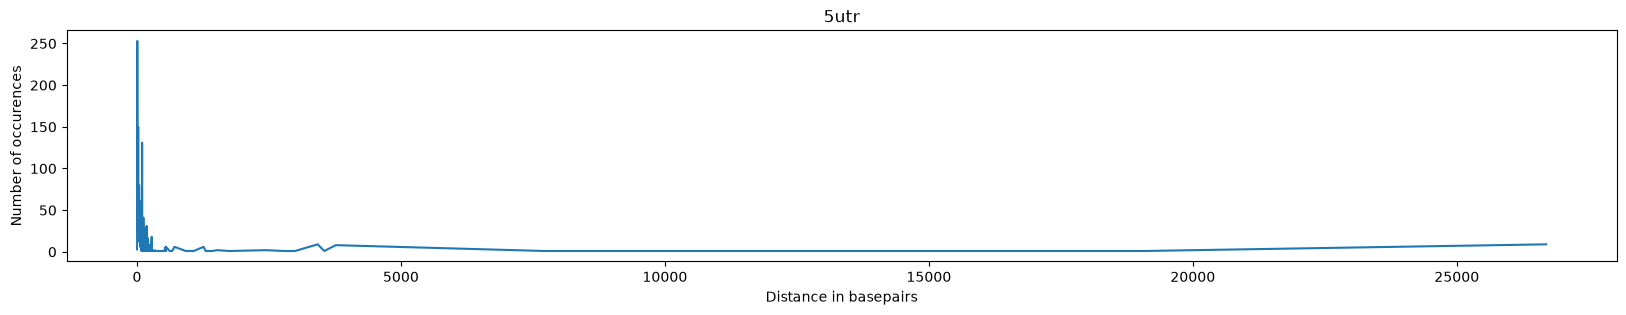

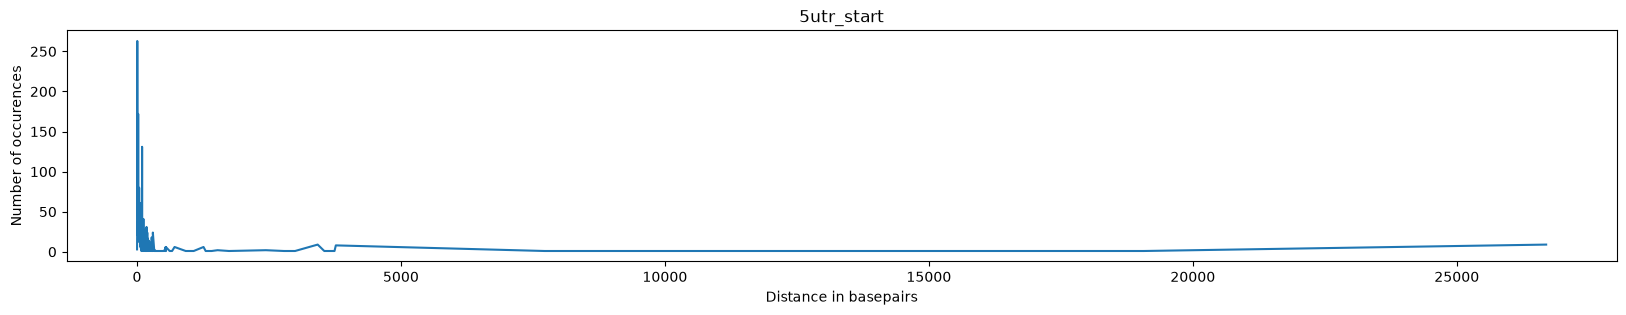

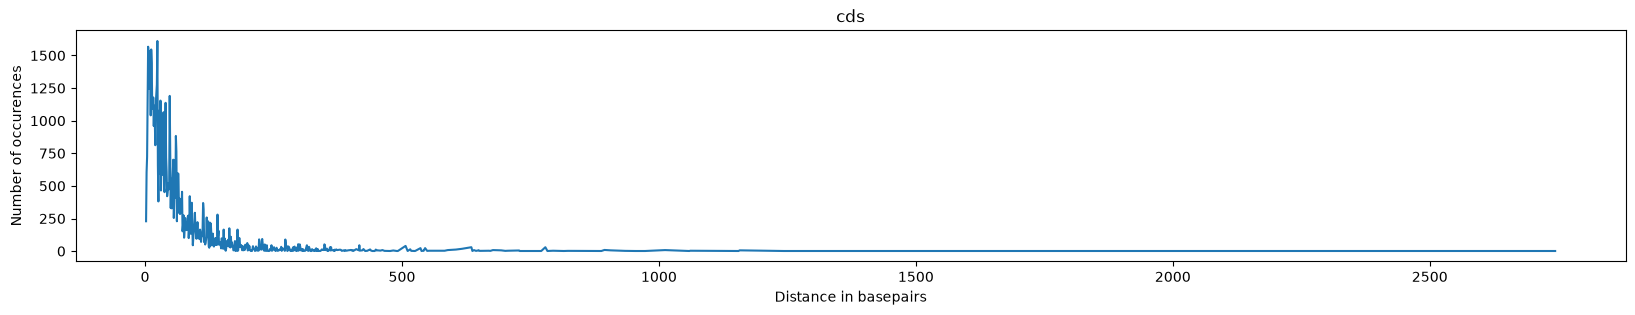

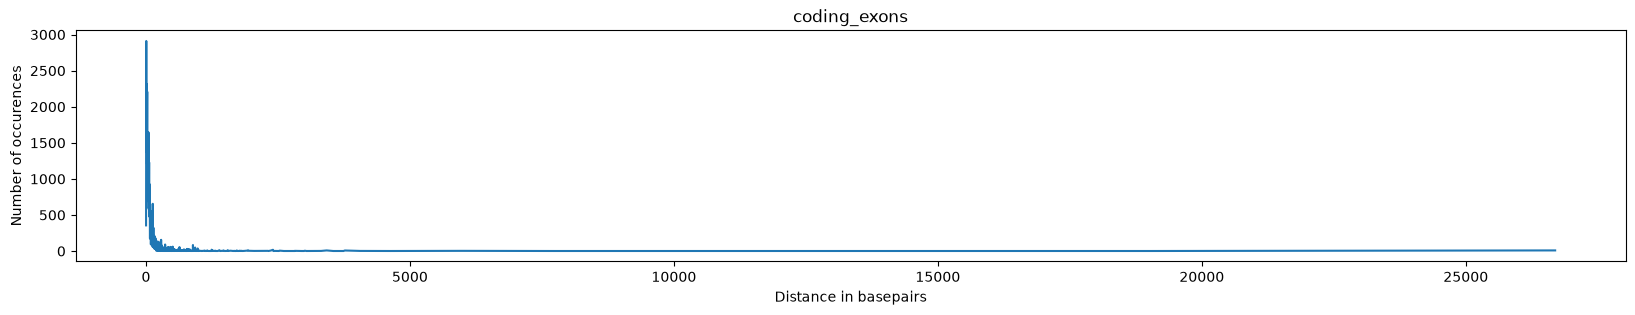

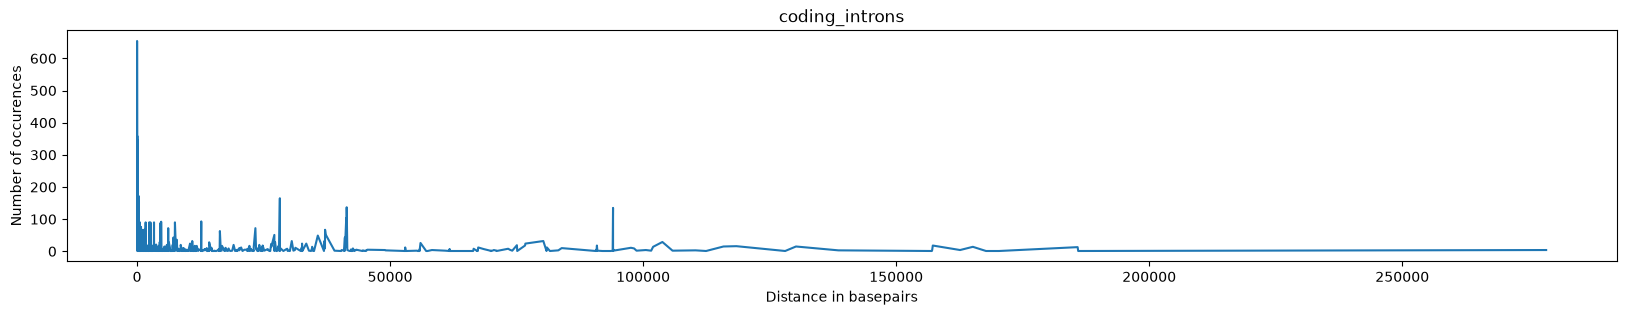

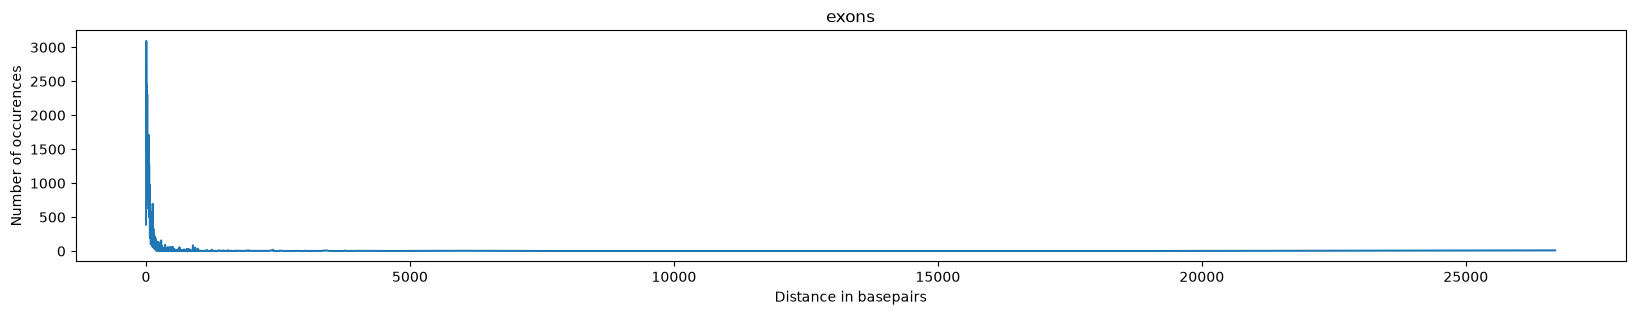

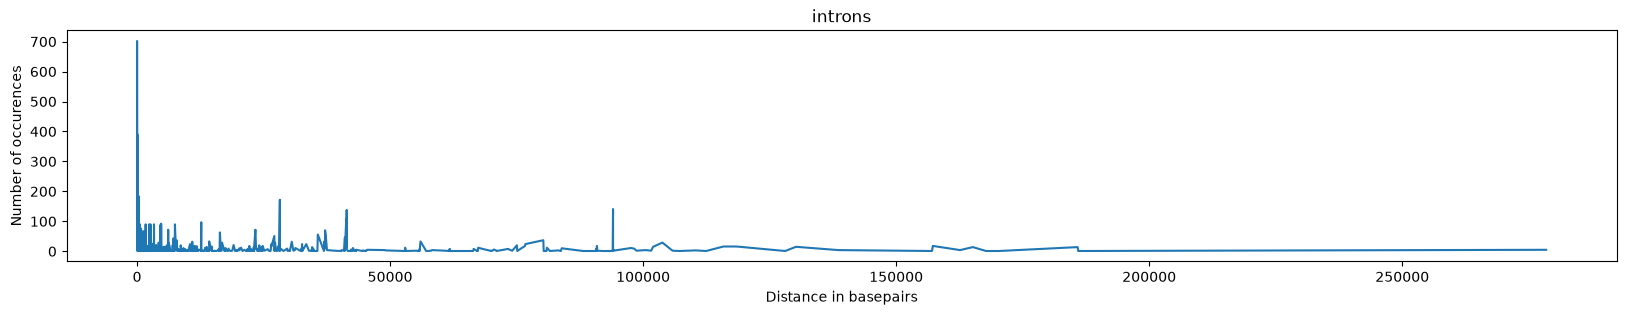

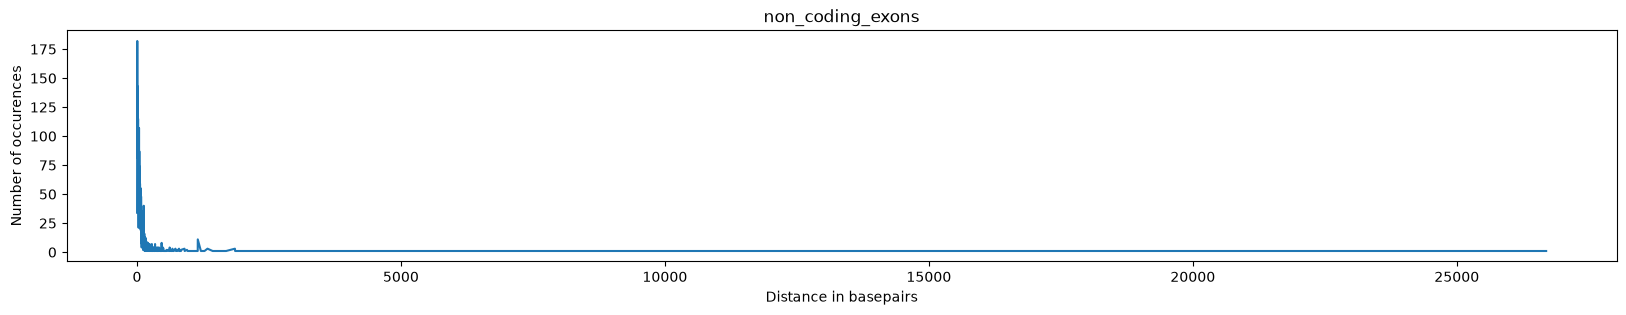

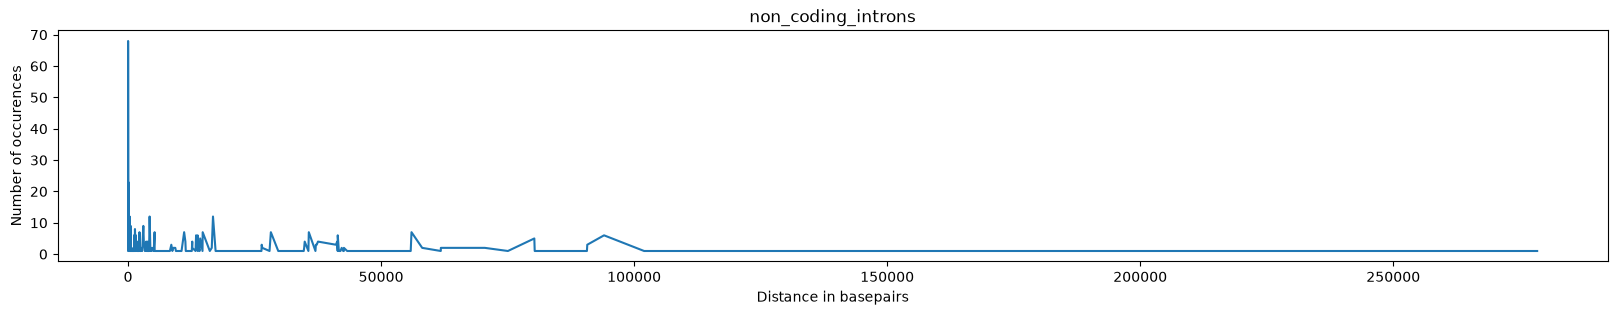

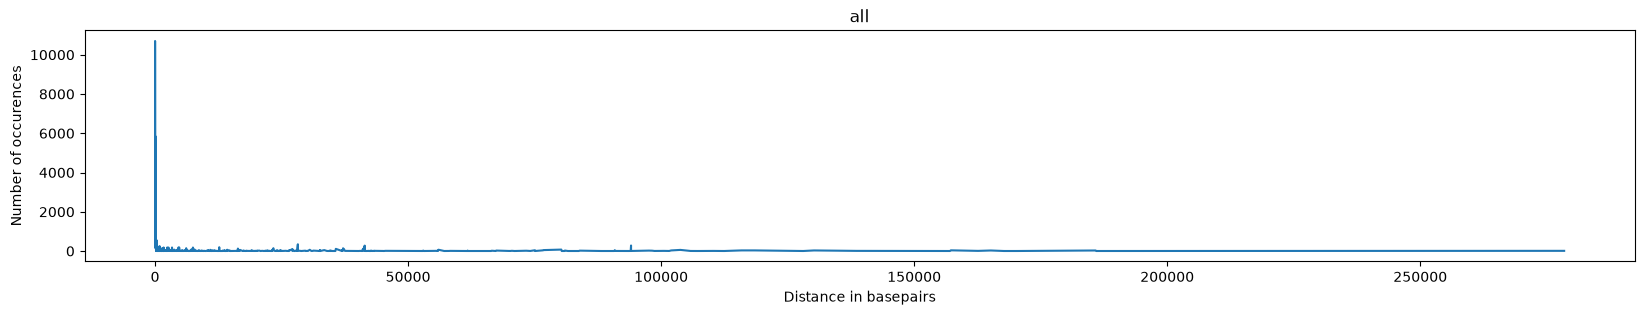

In [4]:
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

distances = {}

def compute_modification_distances(regions):
    local_distances = {}
    
    for region in regions.values():
        modifications = region.modifications

        if len(modifications) < 2:
            continue

        for i in range(len(modifications) - 1):
            first = modifications[i]
            second = modifications[i + 1]

            distance = second - first

            if distance in local_distances:
                local_distances[distance] = local_distances[distance] + 1
            else:
                local_distances[distance] = 1

    return local_distances

for key, file in get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict().items():
    print("Calculating", key)
    regions = load_region_modifications(file)
    
    distances[key] = compute_modification_distances(regions)

all_key_distances = {}

for key in distances.keys():
    for distance in distances[key]:
        if distance in all_key_distances:
            all_key_distances[distance] = all_key_distances[distance] + distances[key][distance]
        else:
            all_key_distances[distance] = distances[key][distance]

distances["all"] = all_key_distances

for key in distances.keys():
    fig, axs = plt.subplots(figsize=(20, 3))
    axs.set_title(key)
    axs.set_xlabel("Distance in basepairs")
    axs.set_ylabel("Number of occurences")
    data_tuples = sorted(distances[key].items(), key=lambda data: data[0])
    data_x = [x[0] for x in data_tuples]
    data_y = [x[1] for x in data_tuples]
    axs.plot(data_x, data_y)

    fig.show()

/tmp/ipykernel_475737/951708412.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


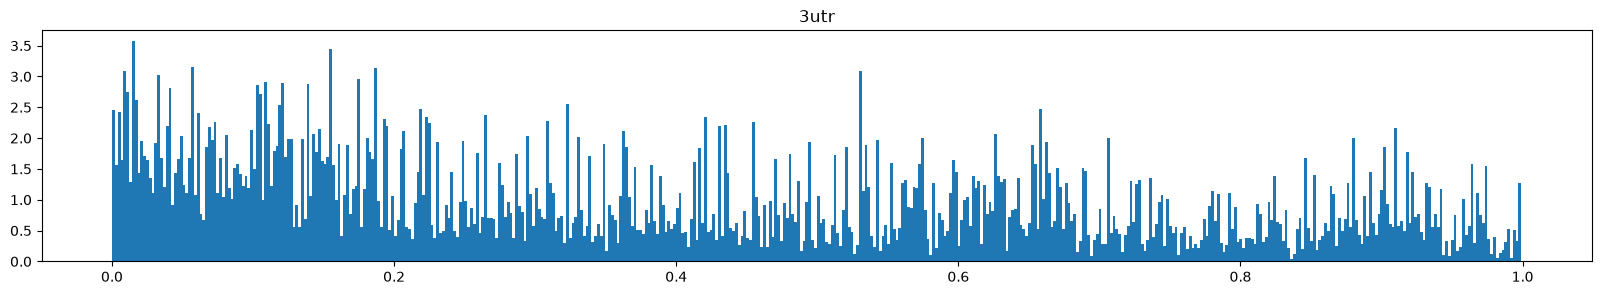

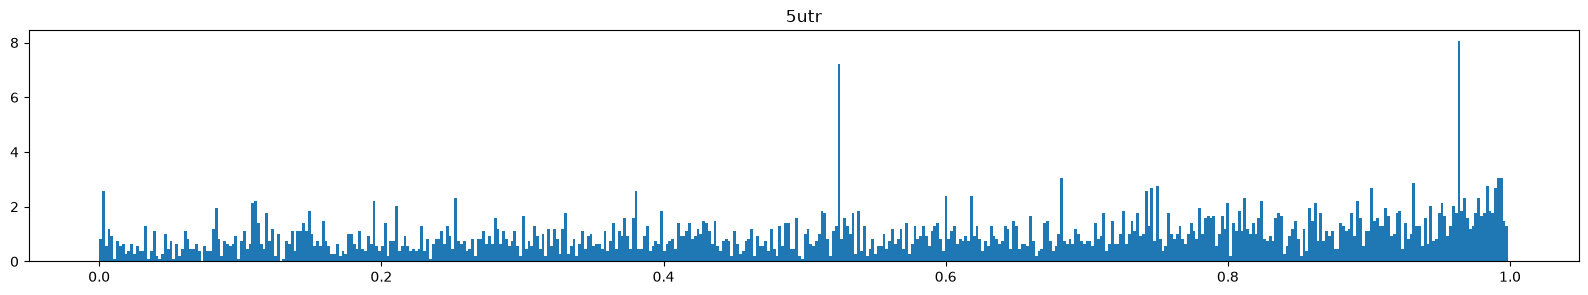

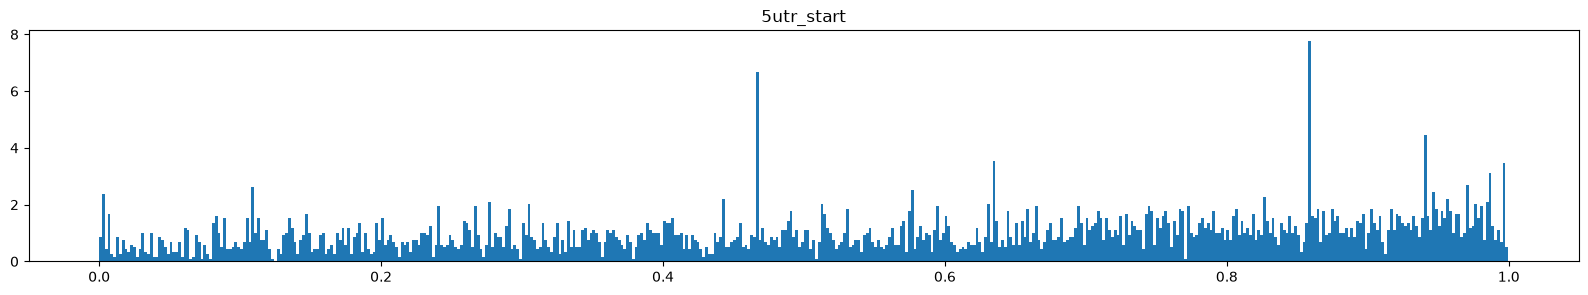

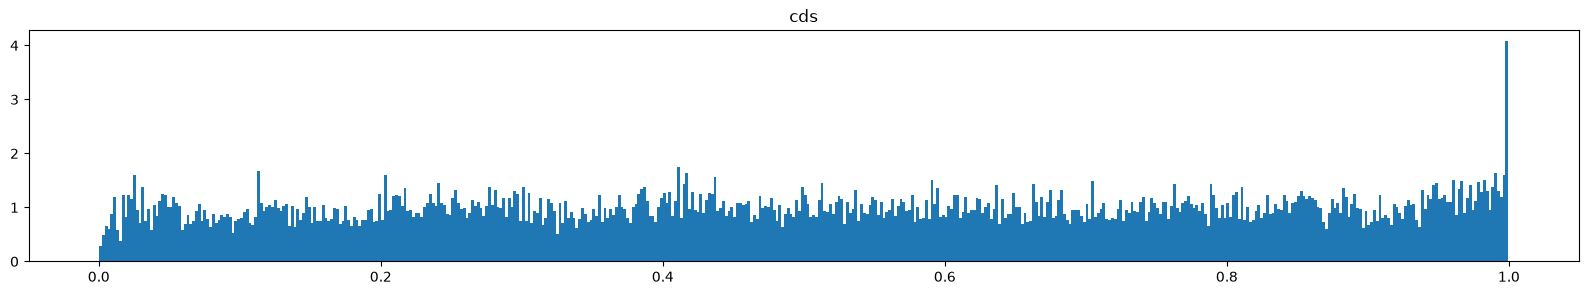

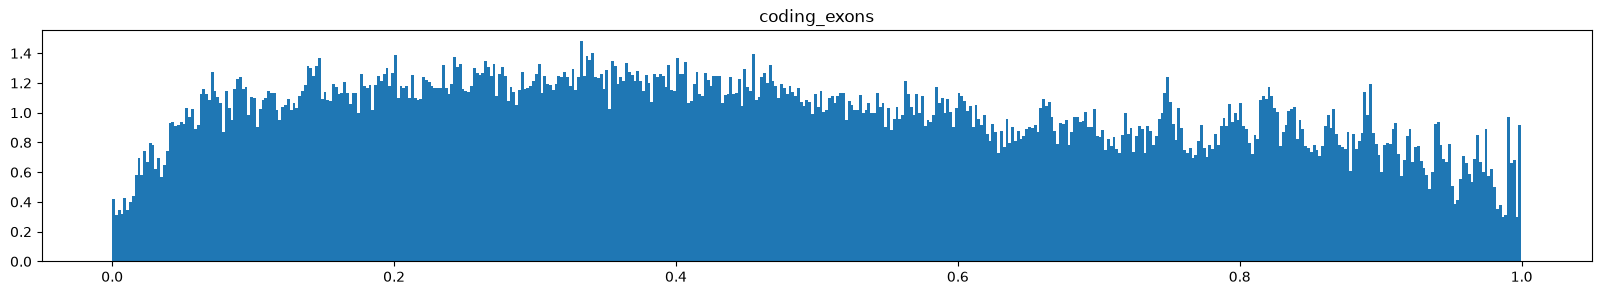

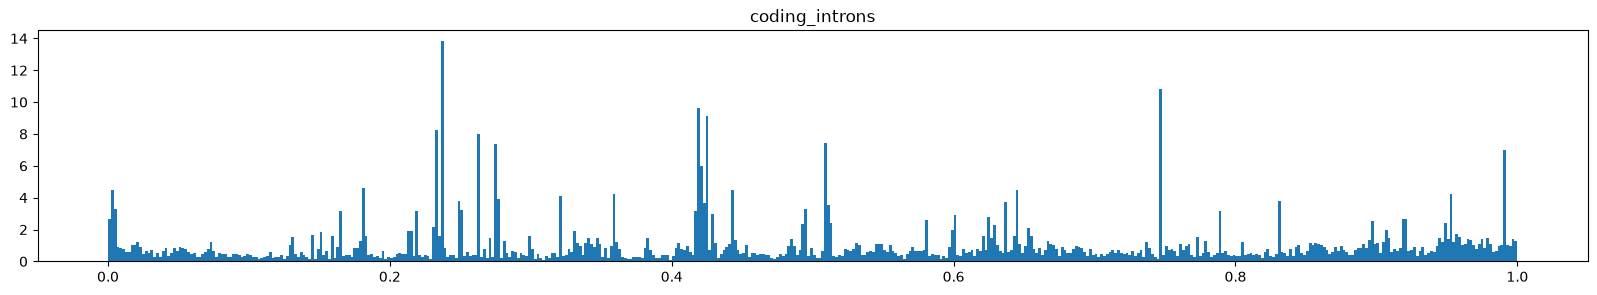

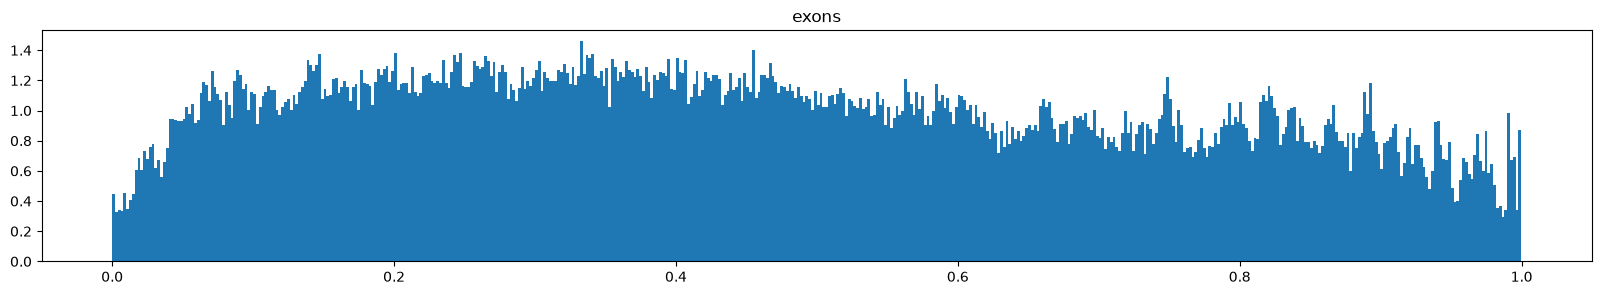

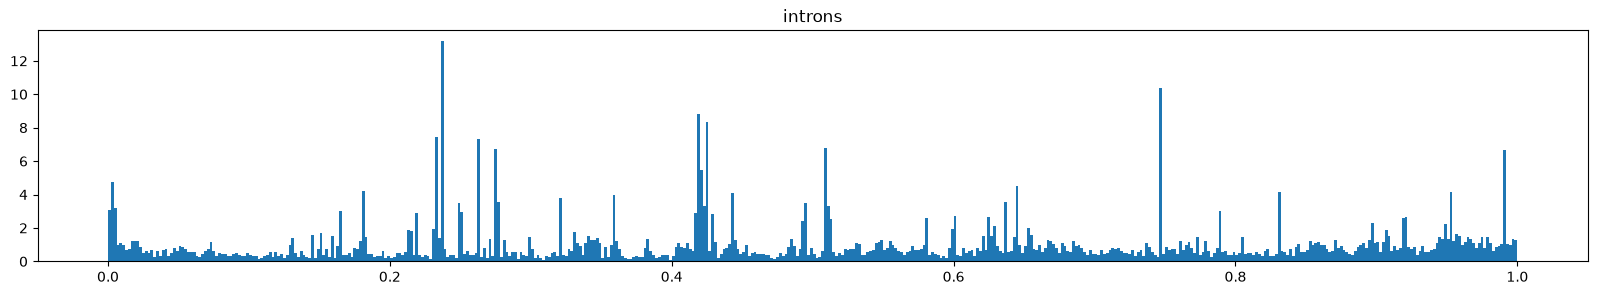

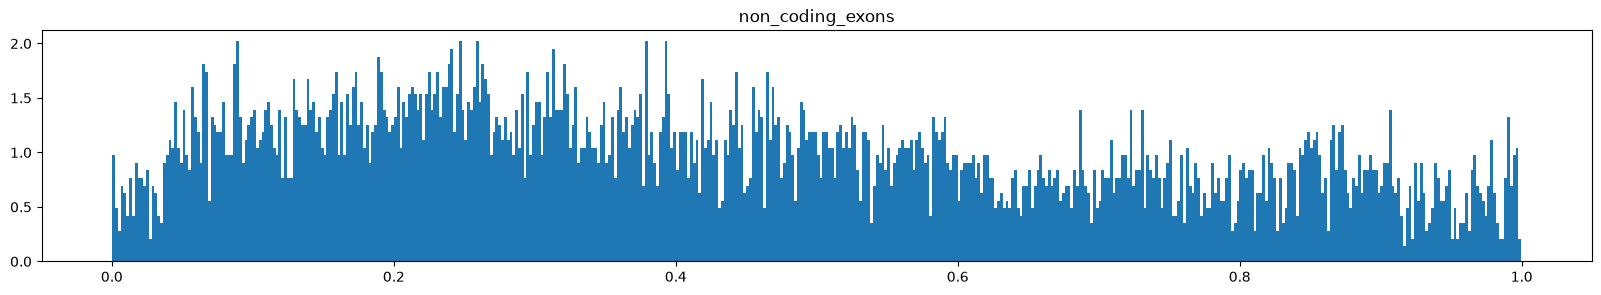

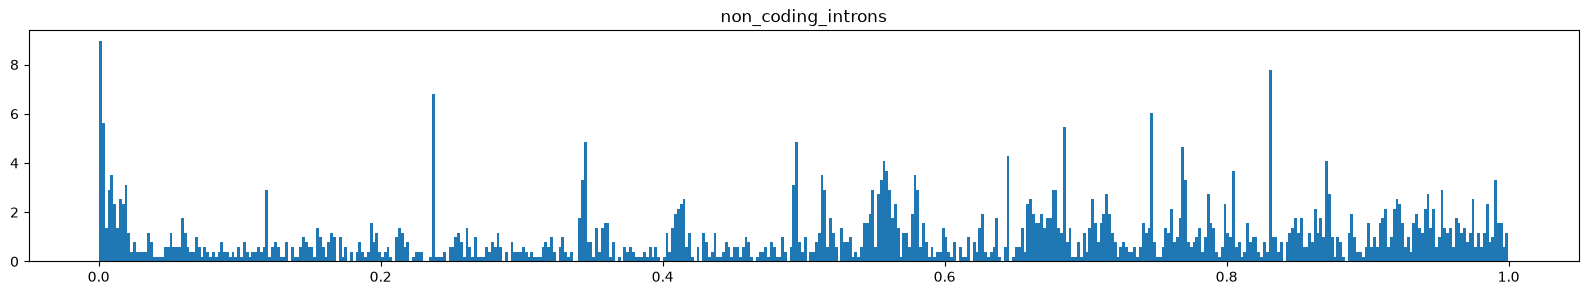

In [31]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import numpy as np

num_bins = 500

relative_positions = {}

for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    relative_positions[key] = []
    
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())

    for entry in fasta_file:
        region_name = entry.name[:entry.name.find(":")]

        if not region_name in regions or len(regions[region_name].modifications) == 0:
            continue
        
        sequence = str(entry.seq)

        sequence_length = len(sequence)

        modifications = regions[region_name].modifications

        for modification in modifications:
            relative_positions[key].append(modification / sequence_length)

for key, data in relative_positions.items():
    fig, axs = plt.subplots(figsize=(20, 3))
    
    axs.hist(data, num_bins, density=1)
    axs.set_title(key)
    
    fig.show()


/tmp/ipykernel_475737/872038206.py:99: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_475737/872038206.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_475737/872038206.py:107: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_475737/872038206.py:111: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


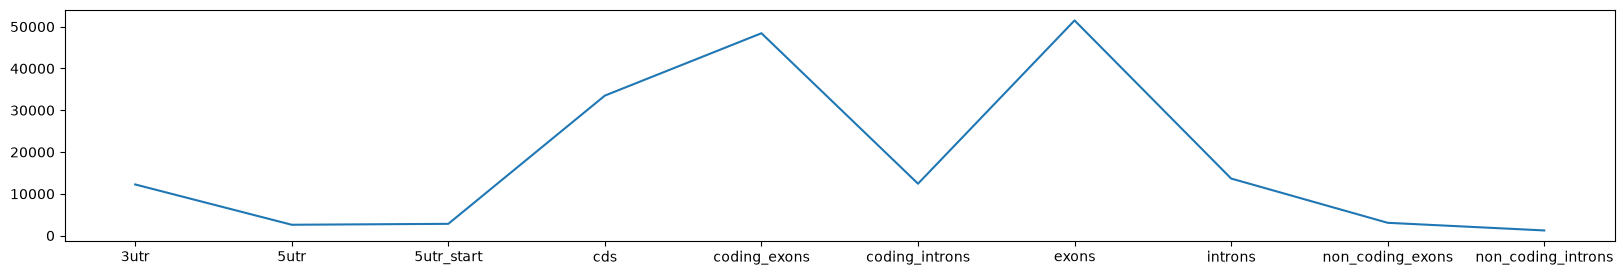

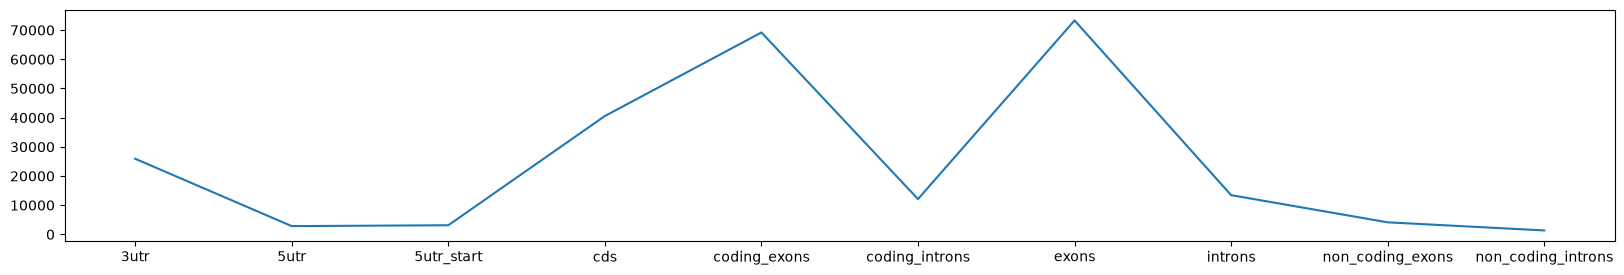

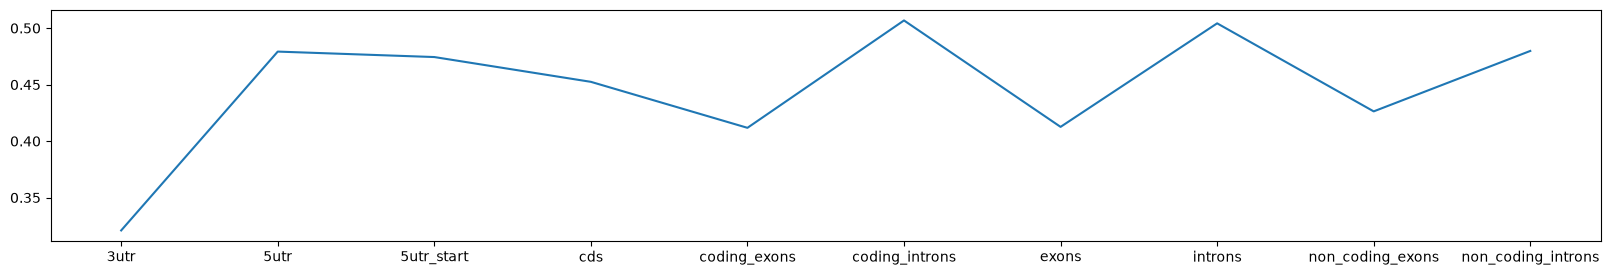

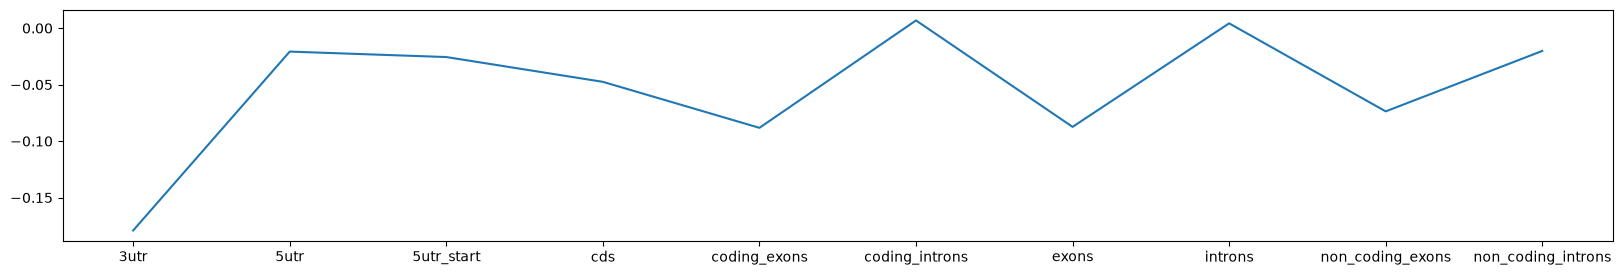

In [19]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files

drach_site_counts = {}
non_drach_site_counts = {}

def is_drach_positive(sequence, position):
    if position < 2 or position > len(sequence) - 3:
        return False

    if not sequence[position - 2] in ["A", "G", "U"]:
        return False

    if not sequence[position - 1] in ["A", "G"]:
        return False

    if sequence[position] != "A":
        print("modification site is not A")

    if sequence[position + 1] != "C":
        return False

    if not sequence[position + 2] in ["A", "C", "U"]:
        return False
    
    return True

def is_drach_negative(sequence, position):
    if position < 2 or position > len(sequence) - 3:
        return False

    if not sequence[position - 2] in ["U", "G", "A"]:
        return False

    if sequence[position - 1] != "G":
        return False

    if sequence[position] != "A":
        print("modification site is not A")

    if not sequence[position + 1] in ["U", "C"]:
        return False

    if not sequence[position + 2] in ["U", "C", "A"]:
        return False
    
    return True

def is_drach(sequence, strand, position):
    if strand == "+":
        return is_drach_positive(sequence, position)
    else:
        return is_drach_negative(sequence, position)

for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    drach_site_counts[key] = 0
    non_drach_site_counts[key] = 0
    
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())

    for entry in fasta_file:
        region_name = entry.name[:entry.name.find(":")]

        if not region_name in regions or len(regions[region_name].modifications) == 0:
            continue
        
        strand = None

        sequence = str(entry.seq).upper().replace("T", "U")
        
        if entry.name.endswith("(+)"):
            strand = "+"
        elif entry.name.endswith("(-)"):
            strand = "-"

        modifications = regions[region_name].modifications

        for modification in modifications:
            if is_drach(sequence, strand, modification):
                drach_site_counts[key] += 1
            else:
                non_drach_site_counts[key] += 1

drach_non_drach_ratios = {}

for key in drach_site_counts.keys():
    drach_site_count = drach_site_counts[key]
    non_drach_site_count = non_drach_site_counts[key]
    total_count = drach_site_count + non_drach_site_count
    
    drach_non_drach_ratios[key] =  drach_site_count / total_count 

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(drach_site_counts.keys(), drach_site_counts.values())
fig.show()

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(non_drach_site_counts.keys(), non_drach_site_counts.values())
fig.show()

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(drach_non_drach_ratios.keys(), drach_non_drach_ratios.values())
fig.show()

fig, axs = plt.subplots(figsize=(20, 3))
axs.plot(drach_non_drach_ratios.keys(), [x - 0.5 for x in drach_non_drach_ratios.values()])
fig.show()


# Accessibility

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1538
5579


/home/erik/bio-prak/mypython/plot.py:43: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


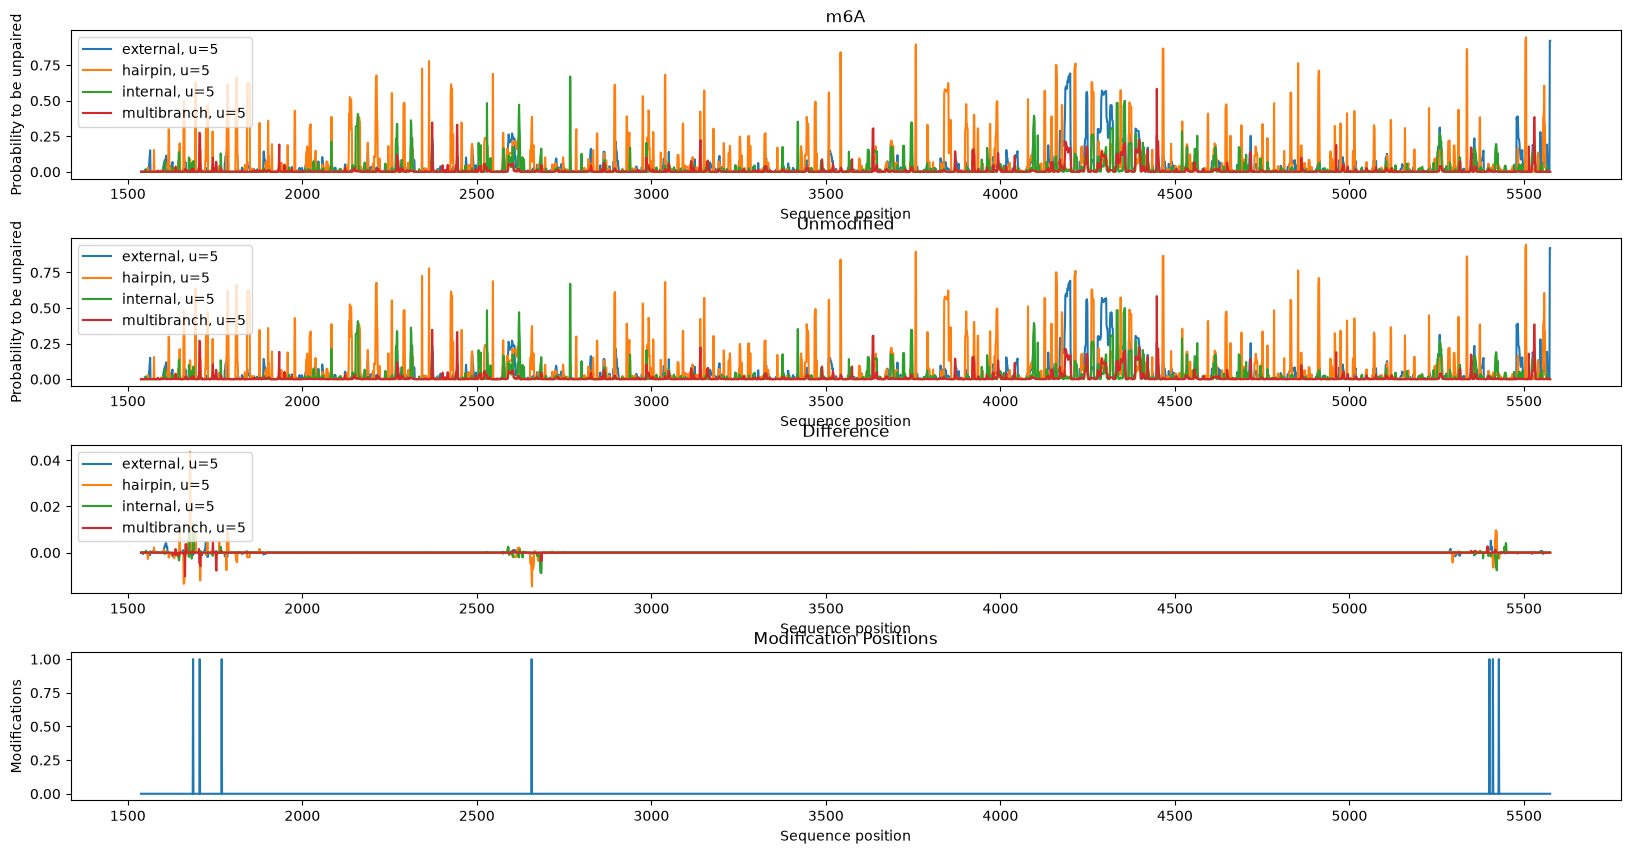

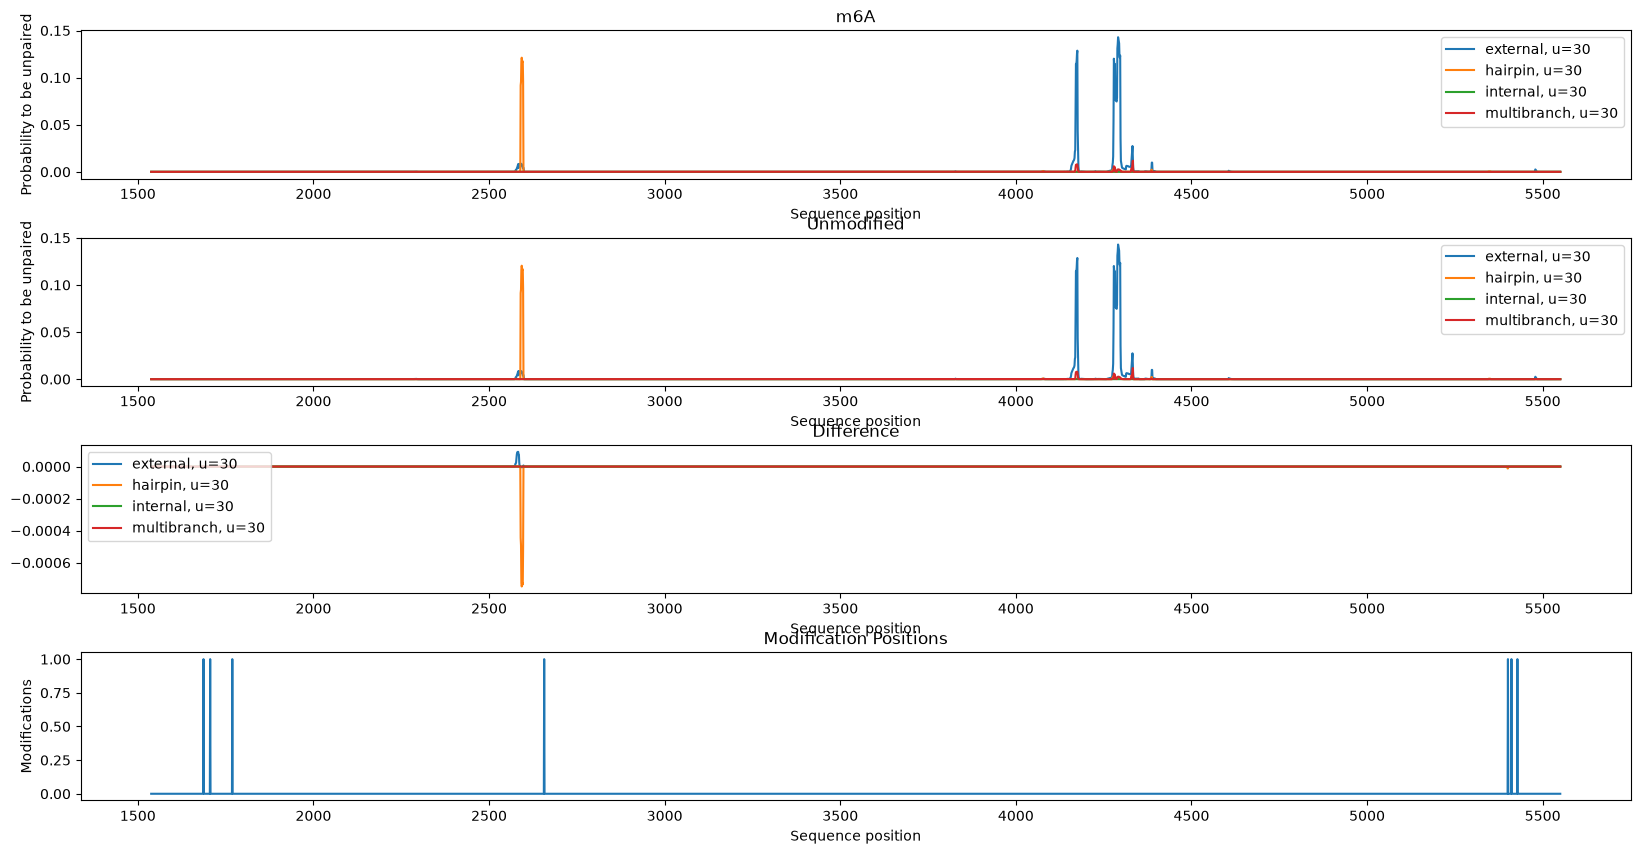

In [5]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

modified_regions = filter(filter_length, filter(filter_entry, map(map_entry, file)))

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    print(modifications)

    start = max(0, modifications[0] - windowsize)
    end = min(len(sequence), modifications[len(modifications) - 1] + windowsize)

    sequence = sequence[start:end]
    modifications = [x - start for x in modifications]
    print(start)
    print(end)
    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)

    plot_accessibilities(sequence, footprints, looptypes, start, end, data, data_unmod, modifications)
    break

# Window Accessibility

In [34]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 10, 15, 20, 25, 30]
windowsize = 150
L = 100

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = [x + 1 for x in regions[region_name].modifications]

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0
    
modified_regions = list(filter(filter_entry, map(map_entry, file)))

num_modified_regions = len(modified_regions)

local_sequence_size = (4 * windowsize) - 1

accumulated_diff_data = {}

for footprint in footprints:
    f_data = {}
    for looptype in looptypes:
        f_data[looptype] = [0.0 for x in range(local_sequence_size - footprint + 2)]
    accumulated_diff_data[footprint] = f_data

print(num_modified_regions)
total_mods = 0
for region_name, sequence, modifications in modified_regions:
    for i in range(len(modifications)):
        if i > 0 and (modifications[i] - modifications[i - 1]) < 2*windowsize:
            continue
        if i < (len(modifications) - 2) and (modifications[i + 1] - modifications[i]) < 2*windowsize:
            continue

        modification = modifications[i]
        
        start = modification - 2*windowsize

        if start < 0:
            continue

        end = modification + 2*windowsize - 1

        if end > len(sequence):
            continue

        local_sequence = sequence[start:end]
        local_modification = [modification - start]
        
        local_data_unmod = accessibility(local_sequence, footprints, windowsize = windowsize, L = L)
        local_data = accessibility(local_sequence, footprints, windowsize = windowsize, L = L, m6A_sites = local_modification)

        for footprint in footprints:
            for looptype in local_data[footprint]:
                diff = [v for v in map(lambda pair: pair[1] - pair[0], zip(local_data[footprint][looptype], local_data_unmod[footprint][looptype]))]

                for i in range(len(diff)):
                    diff_value = diff[i]

                    accumulated_diff_data[footprint][looptype][i] += diff_value
        
        total_mods += 1

print(total_mods)


2621
723


In [35]:
average_diff_data = {}

for footprint in accumulated_diff_data:
    avg_f_data = {}
    for looptype in accumulated_diff_data[footprint]:
        avg_f_data[looptype] = [x / total_mods for x in accumulated_diff_data[footprint][looptype]]
    average_diff_data[footprint] = avg_f_data

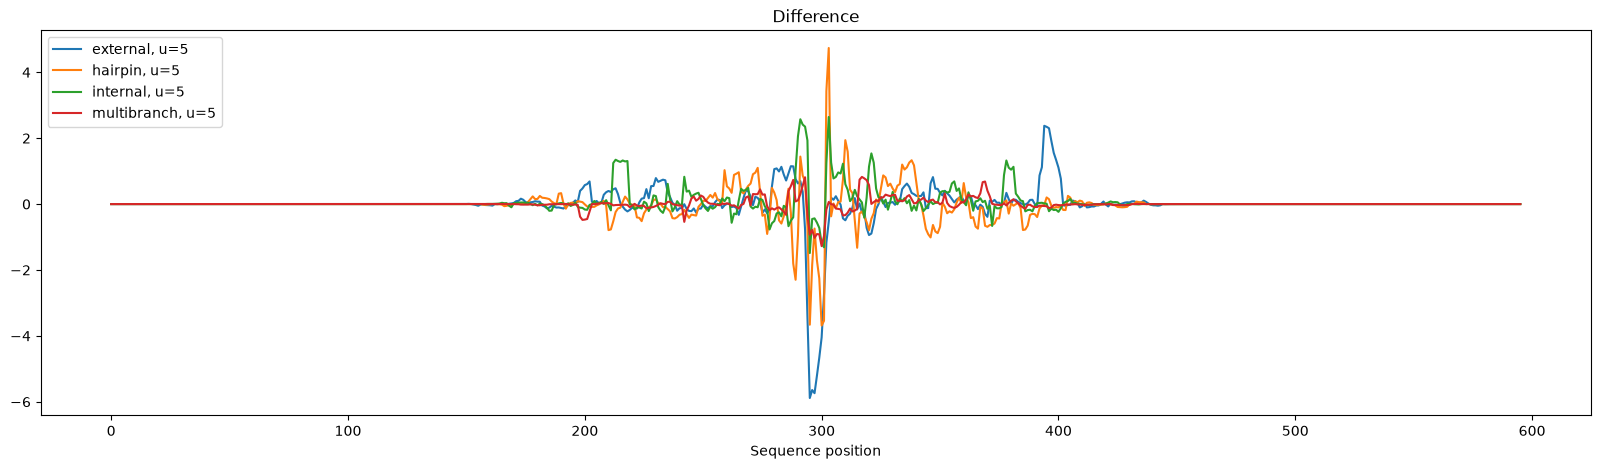

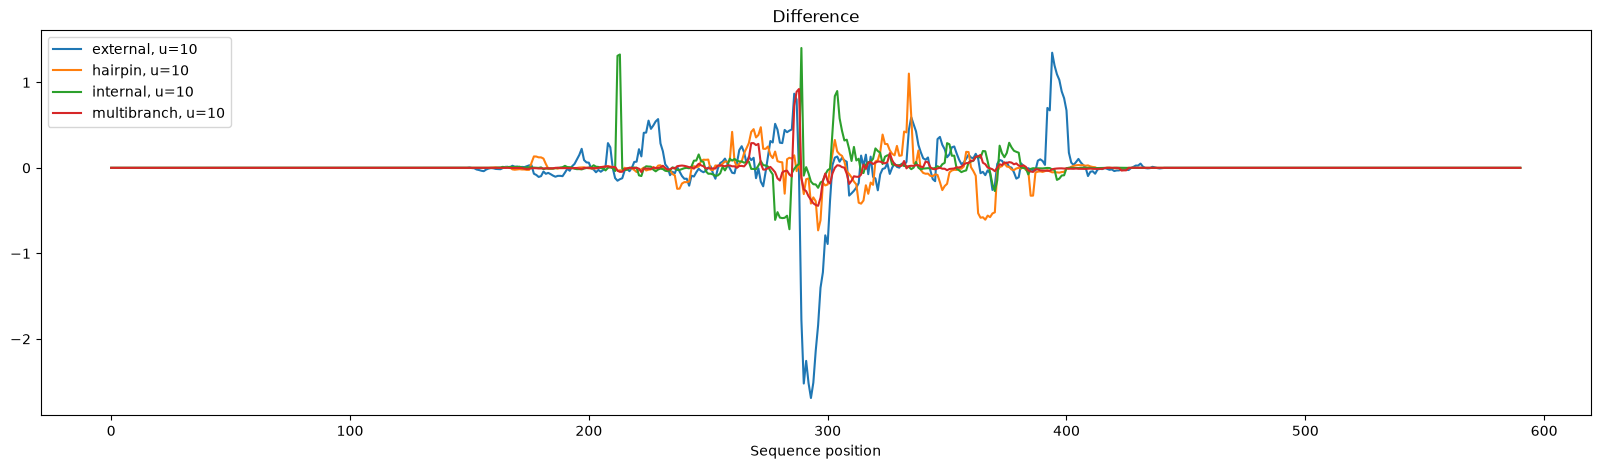

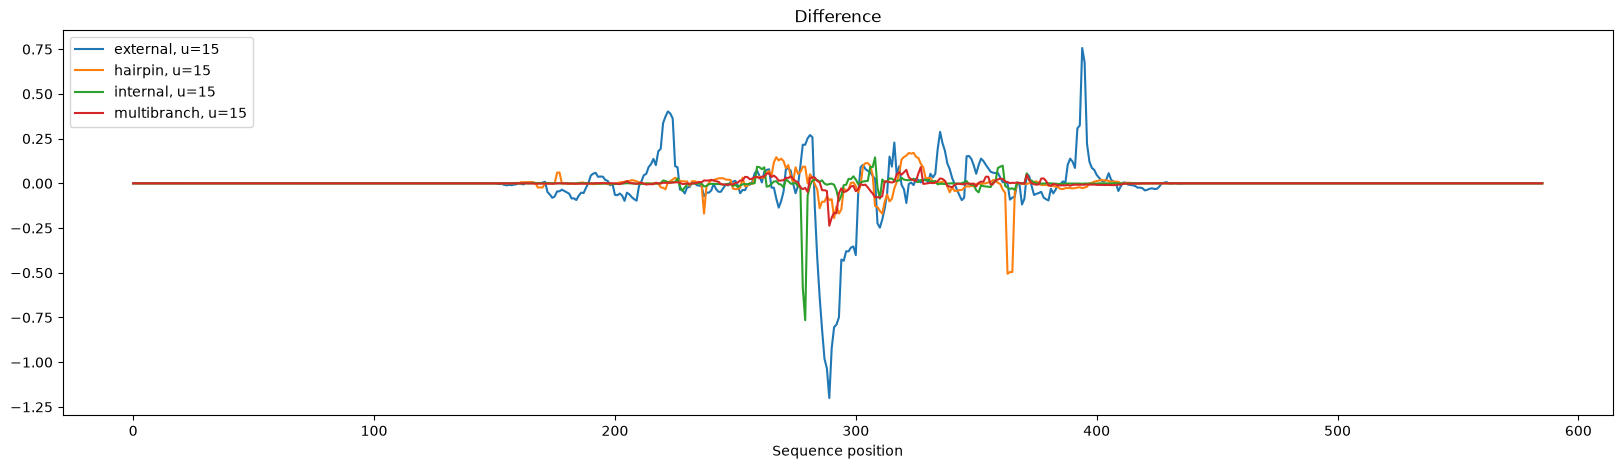

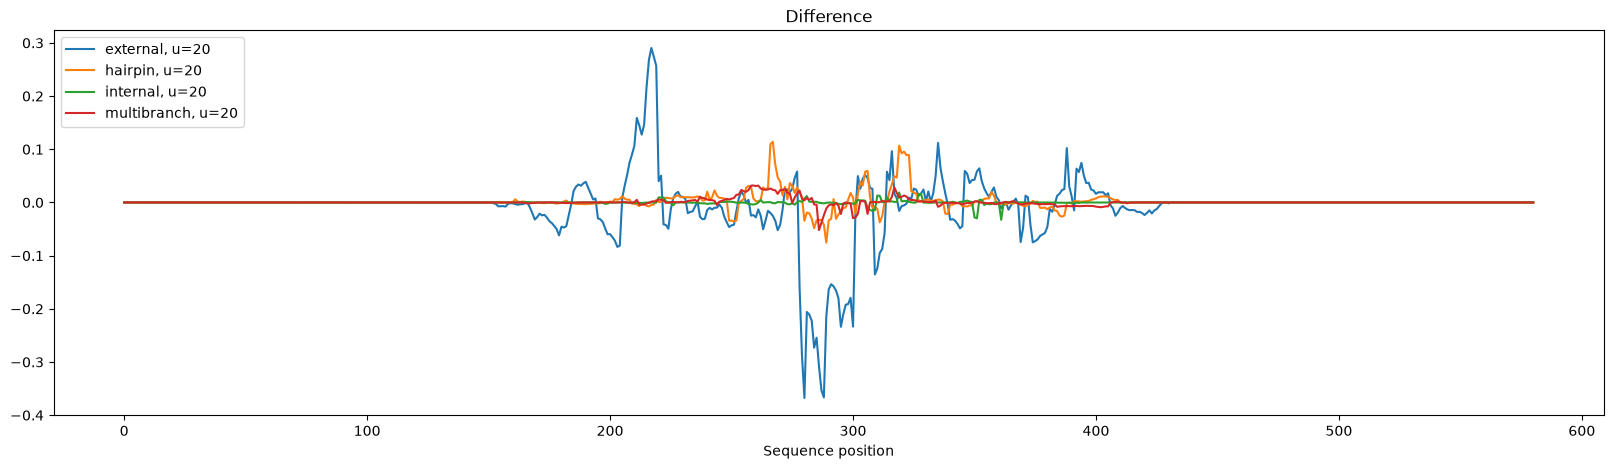

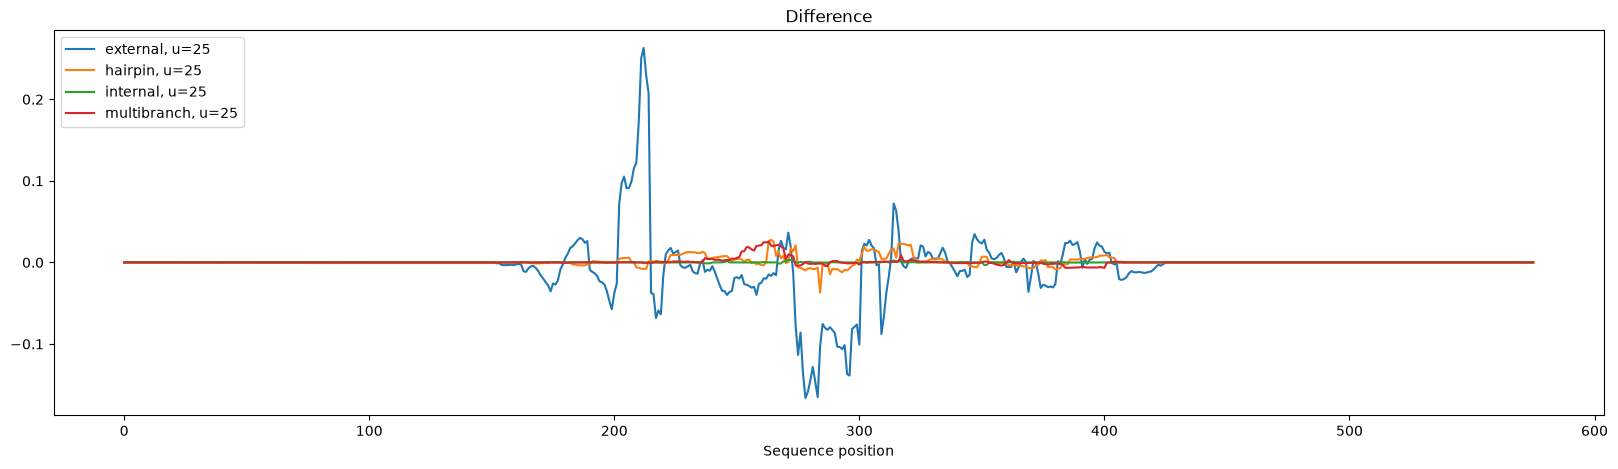

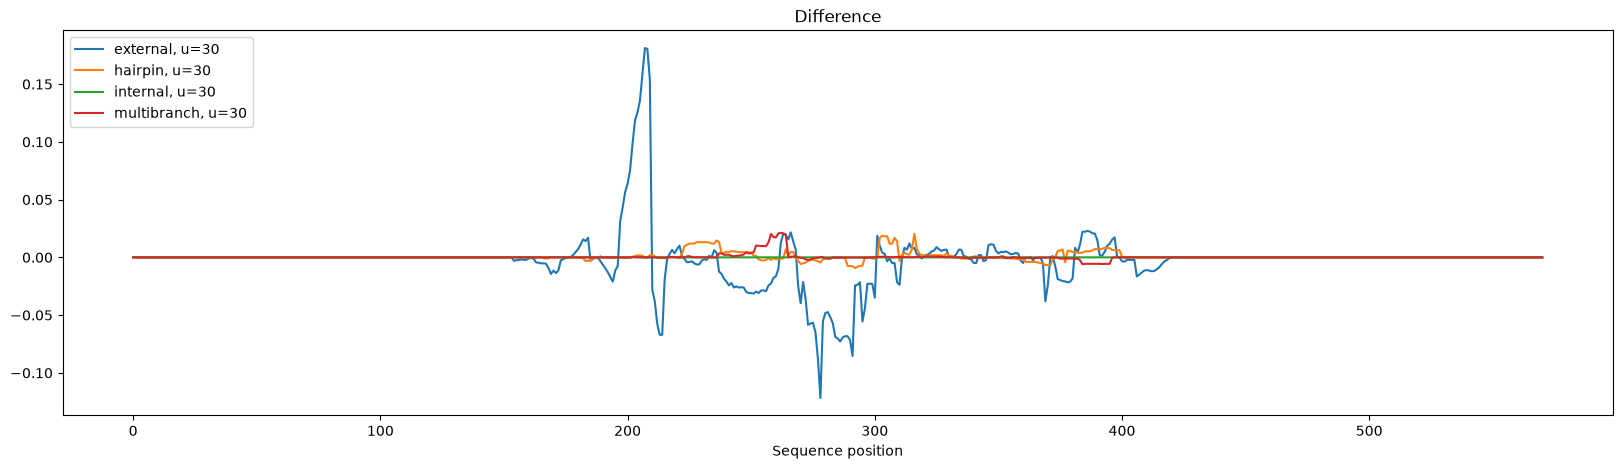

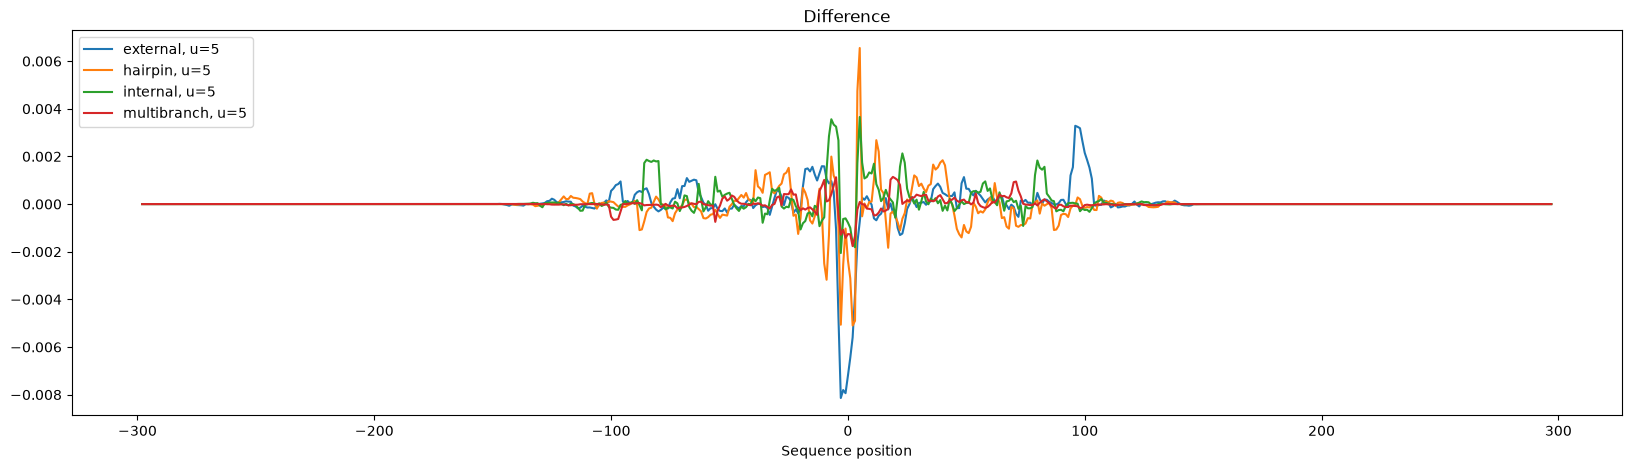

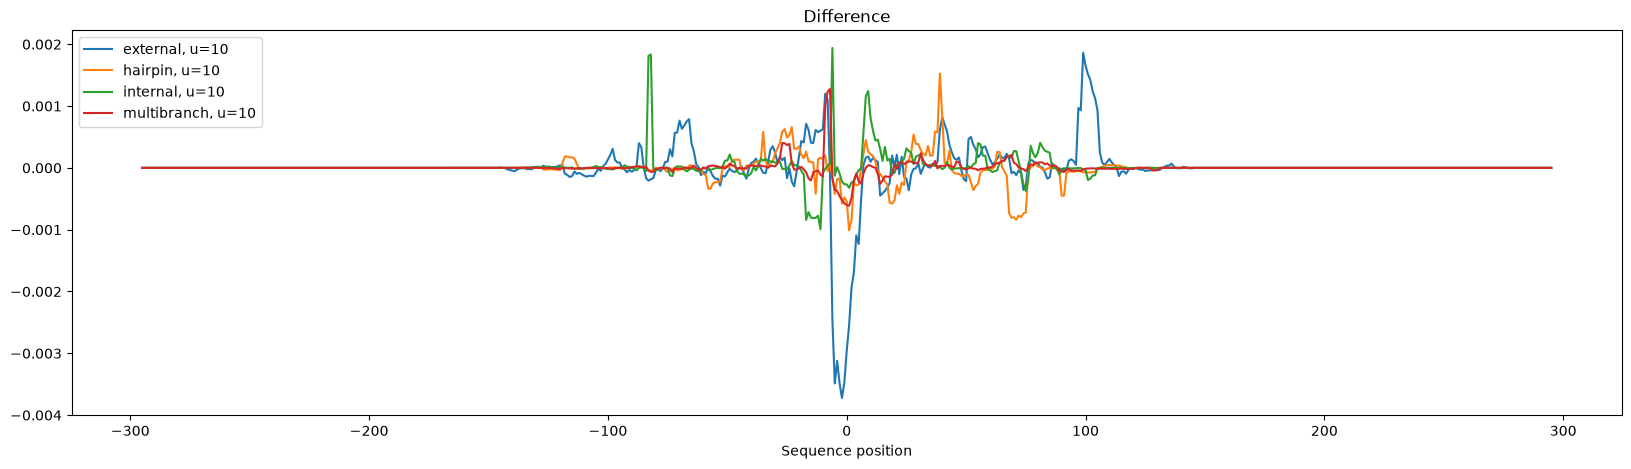

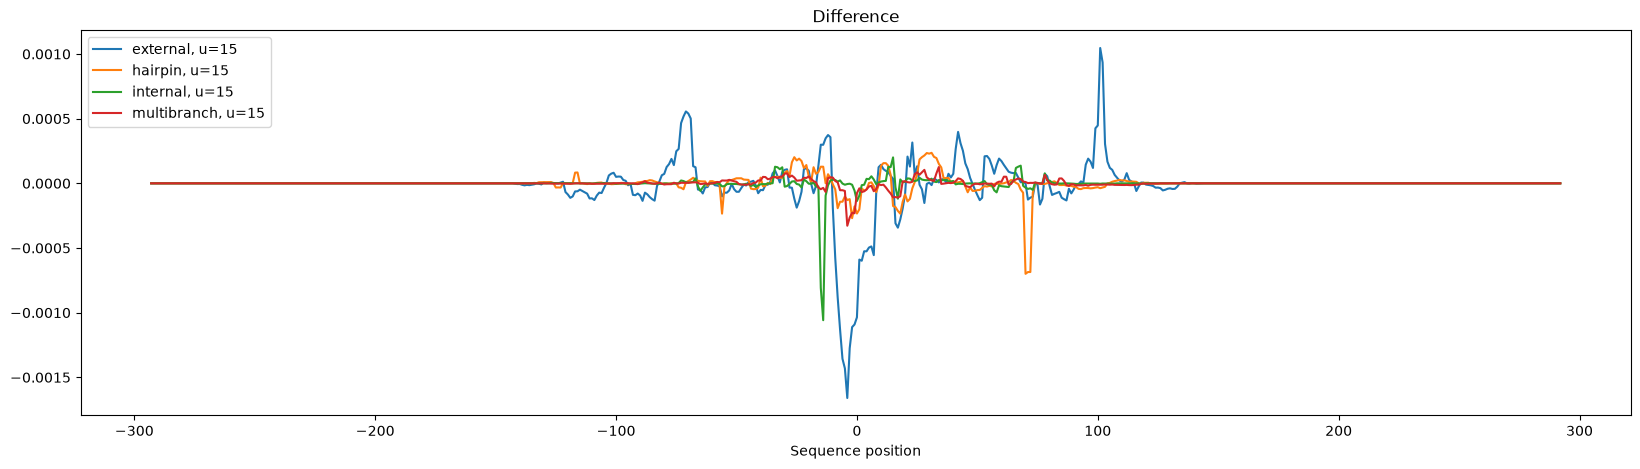

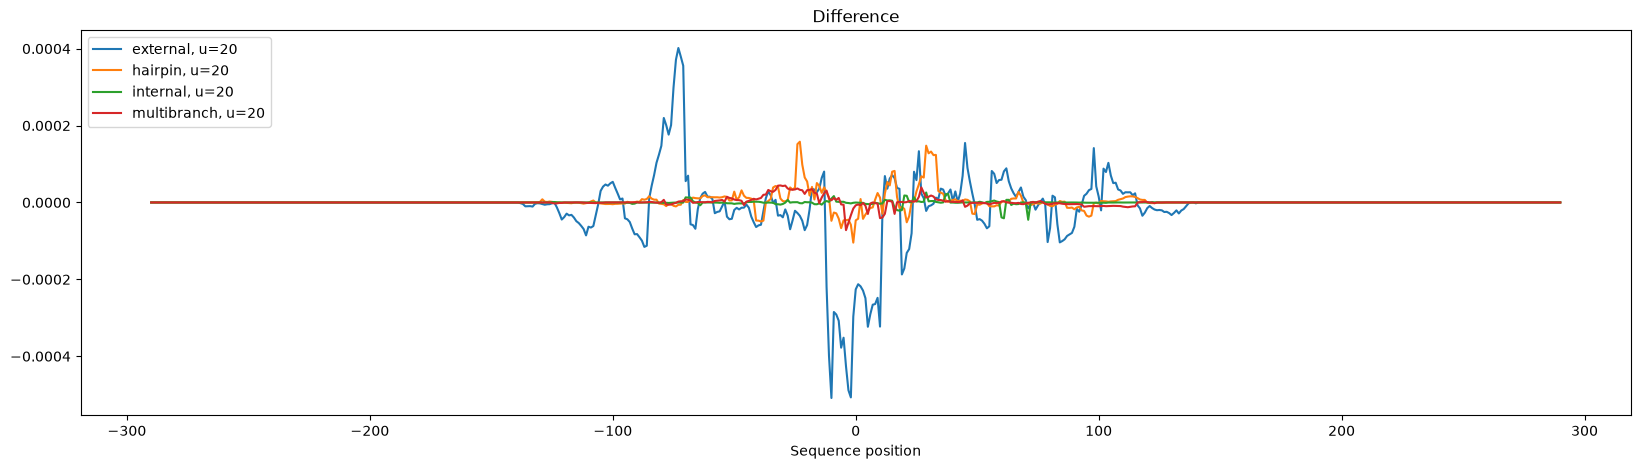

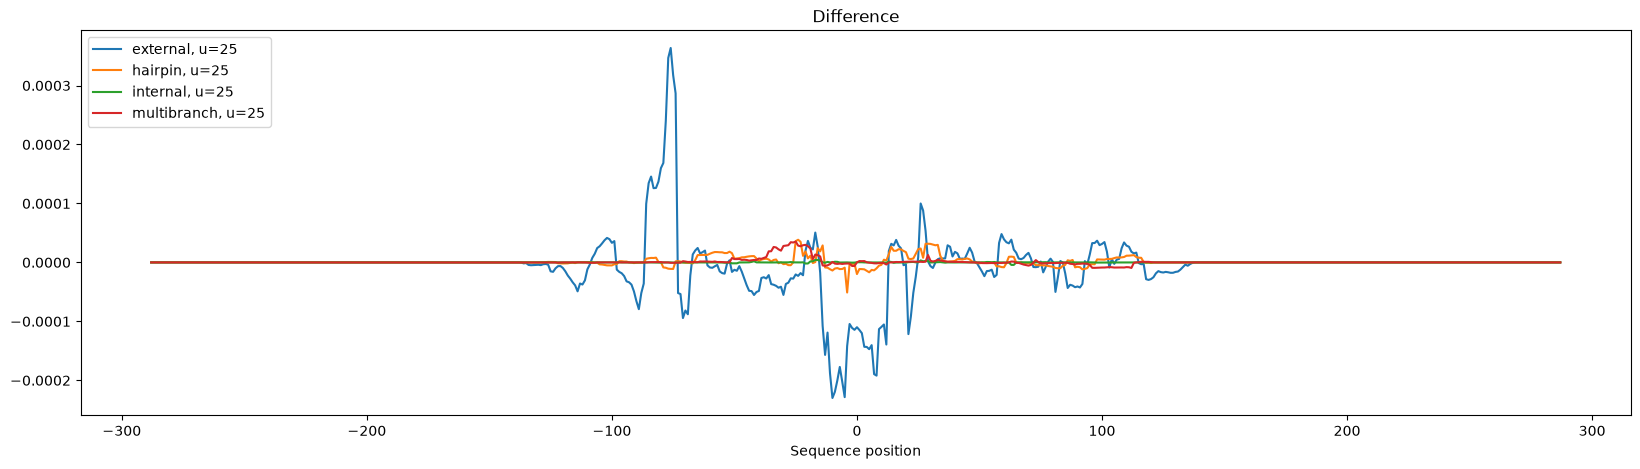

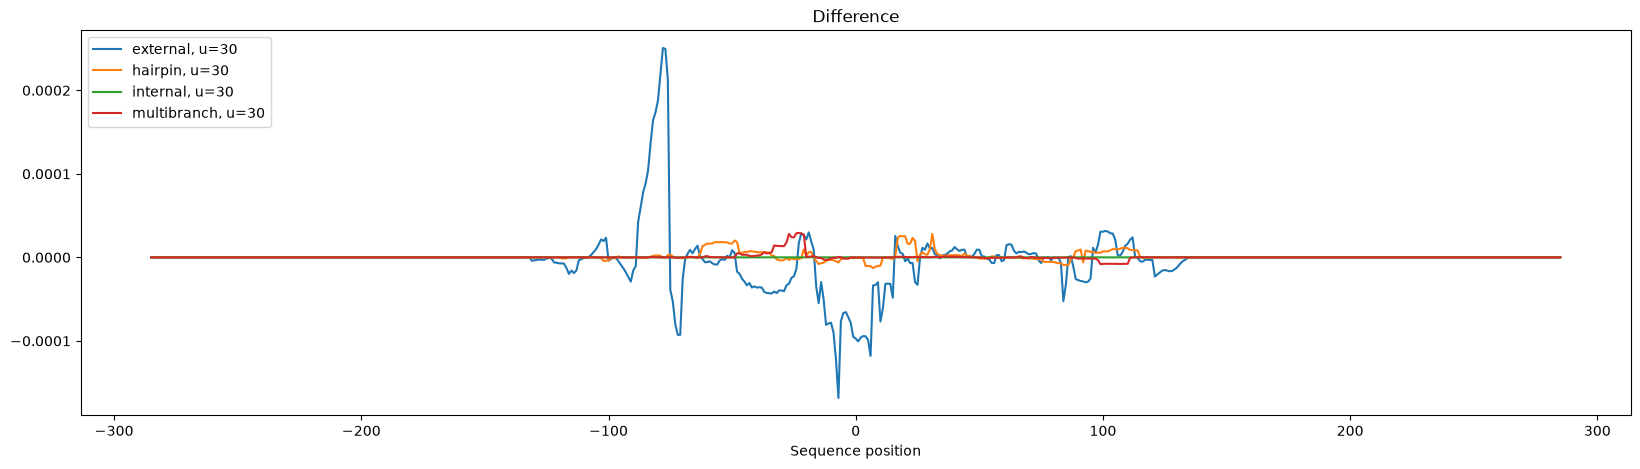

In [37]:
for footprint in accumulated_diff_data:
    fig, axs = plt.subplots(figsize = (20, 5))

    for looptype, values in accumulated_diff_data[footprint].items():
        axs.plot([i for i in range(len(values))], values, label = "{}, u={:d}".format(looptypes[looptype], footprint))
    axs.set_title("Difference")
    axs.set_xlabel("Sequence position")
    axs.legend(loc="upper left")
    
for footprint in average_diff_data:
    fig, axs = plt.subplots(figsize = (20, 5))

    for looptype, values in average_diff_data[footprint].items():
        half_length = int(len(values) / 2)
        axs.plot([i - half_length for i in range(len(values))], values, label = "{}, u={:d}".format(looptypes[looptype], footprint))
    axs.set_title("Difference")
    axs.set_xlabel("Sequence position")
    axs.legend(loc="upper left")

# Sanity check windowing

NM_178857.6_exon
8014
[1688, 1707, 1770, 2658, 5402, 5412, 5429]
1538
5579


/tmp/ipykernel_22034/3847365759.py:138: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


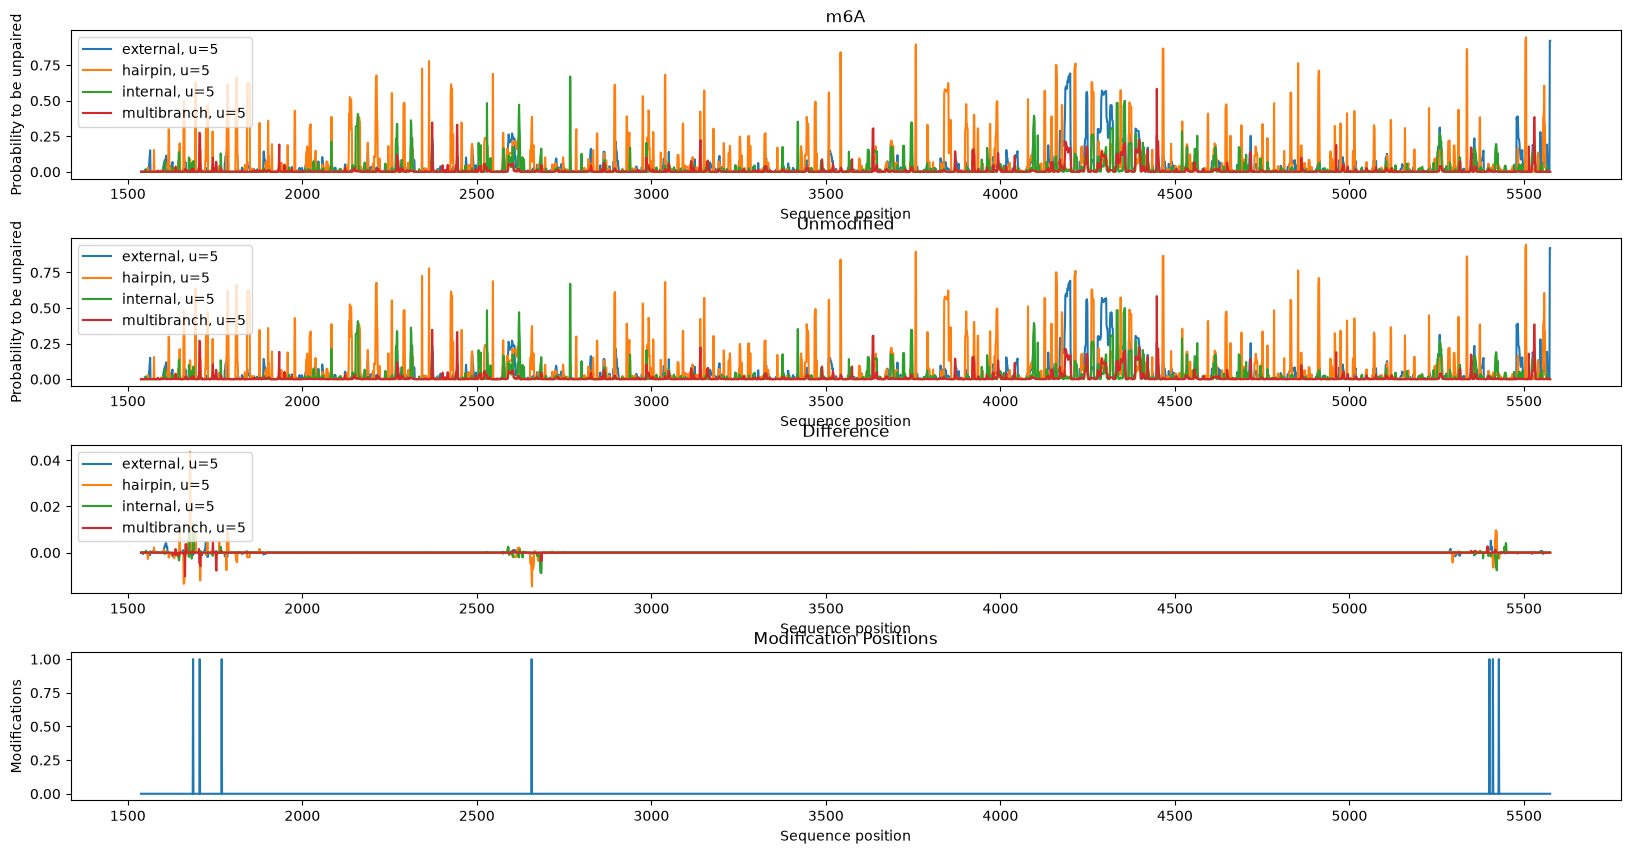

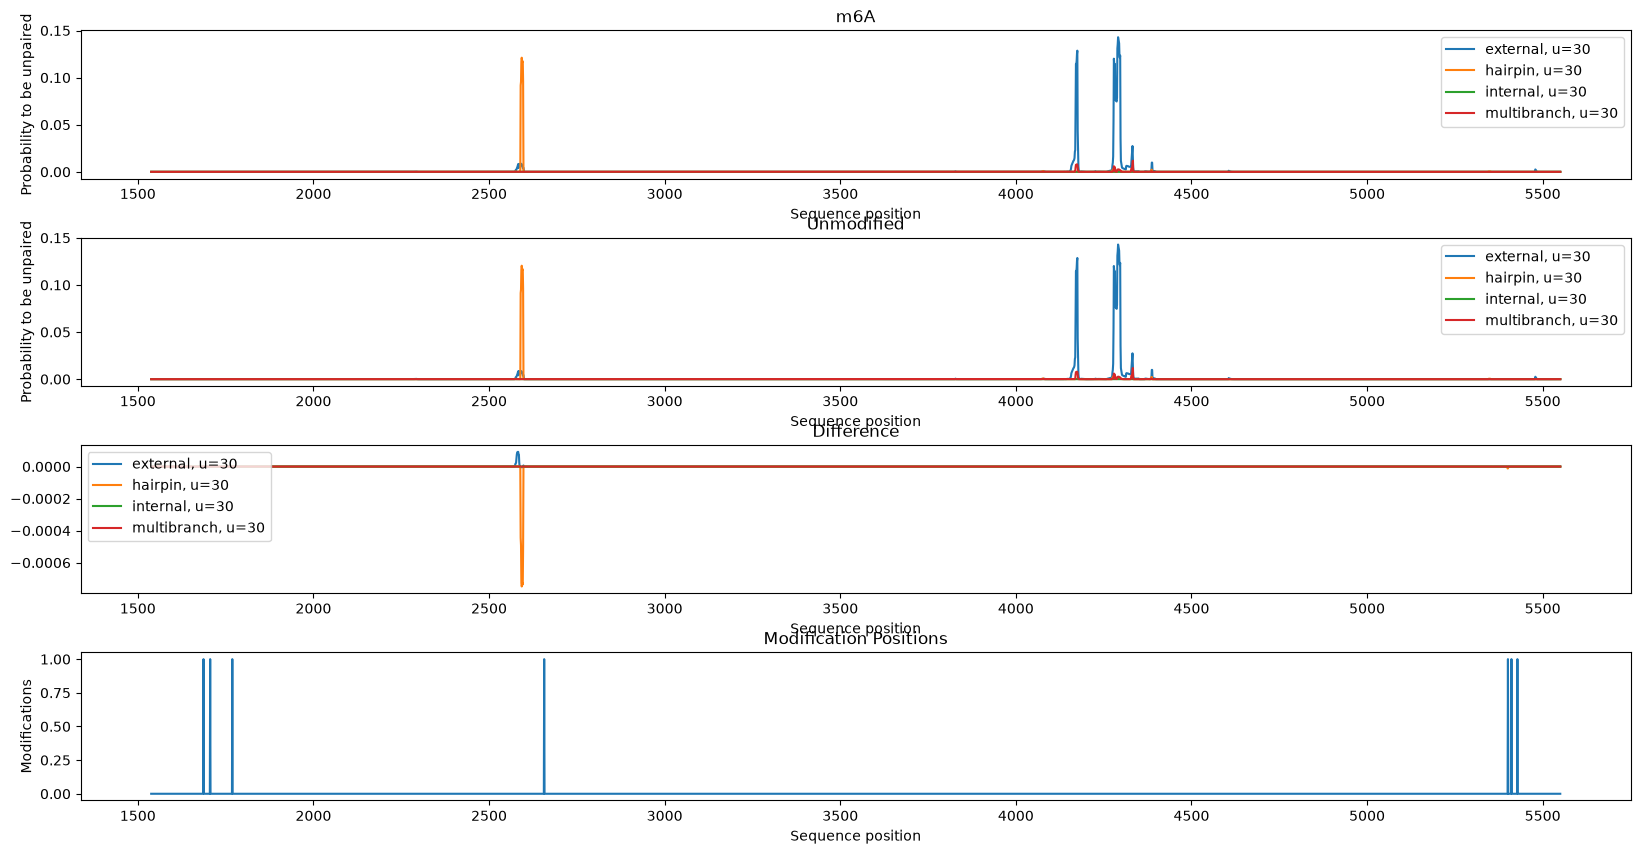

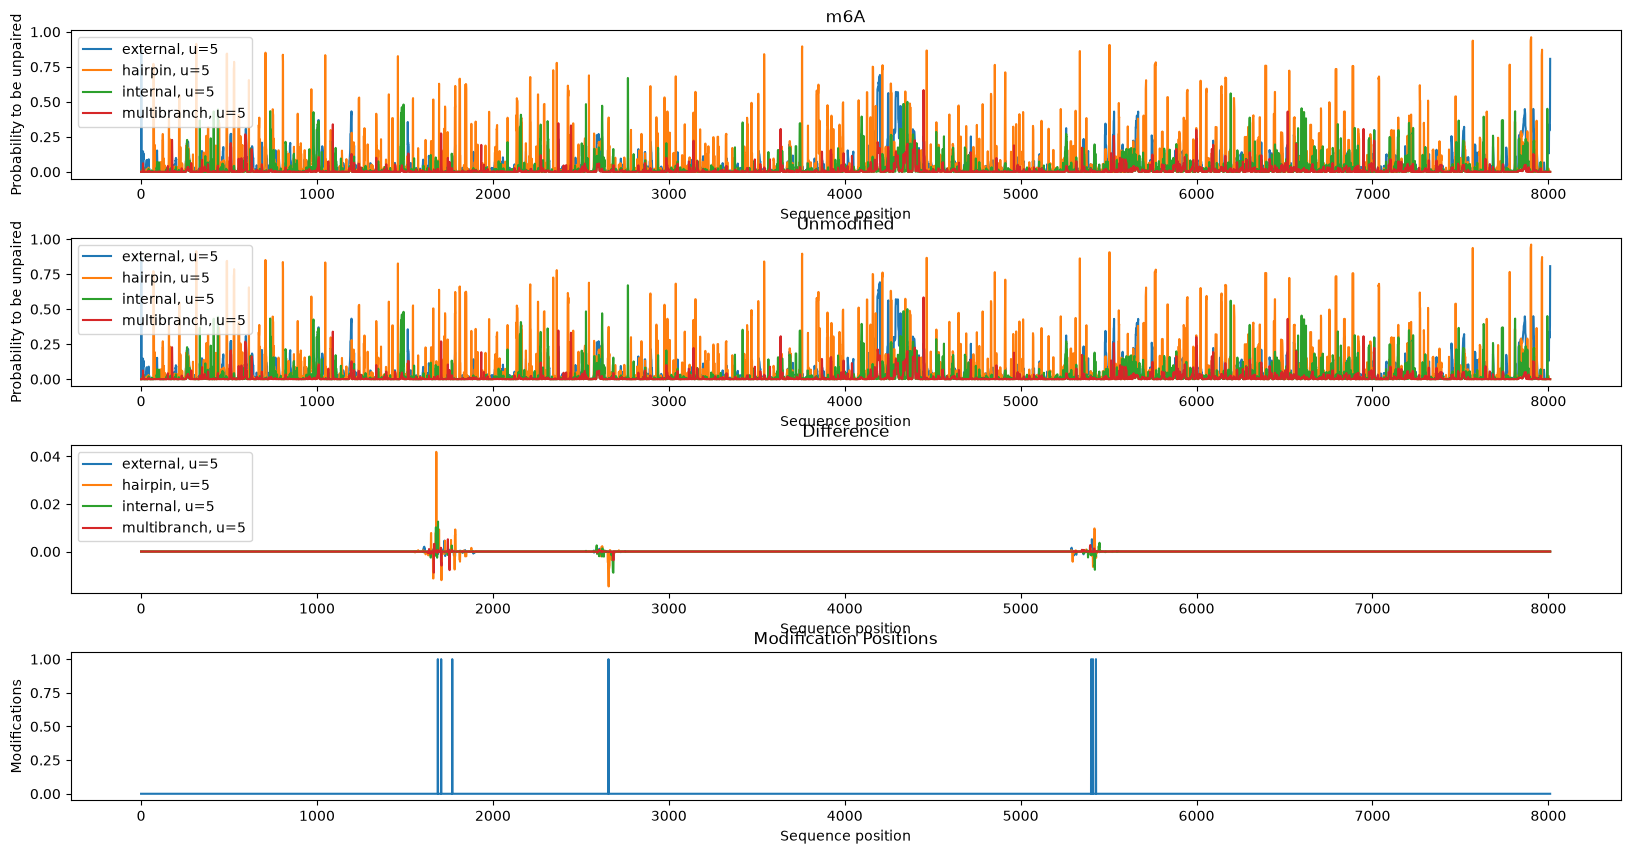

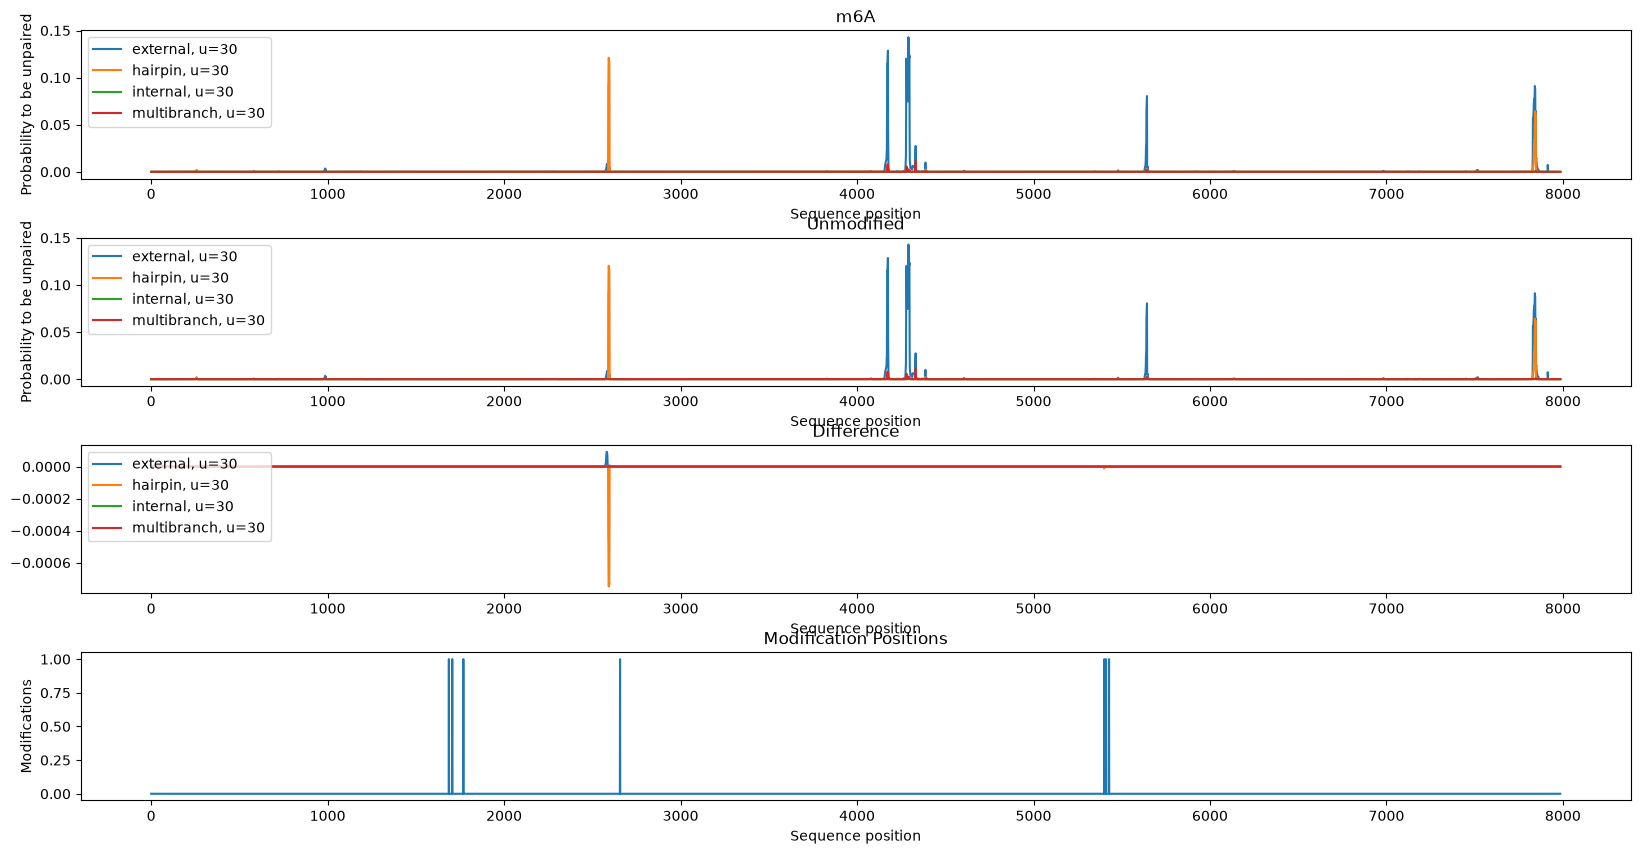

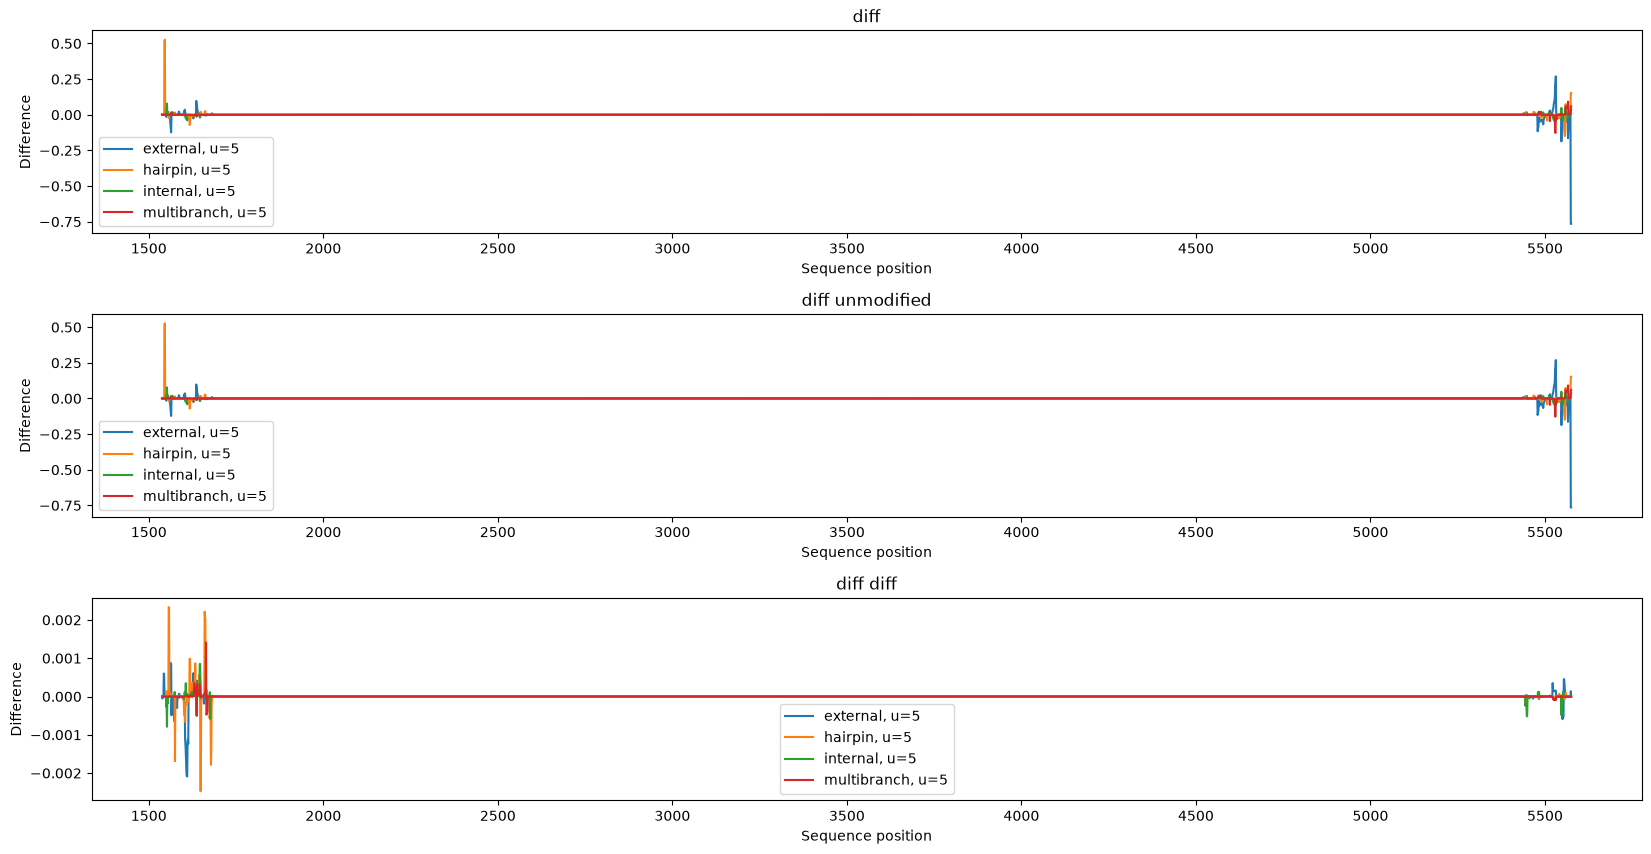

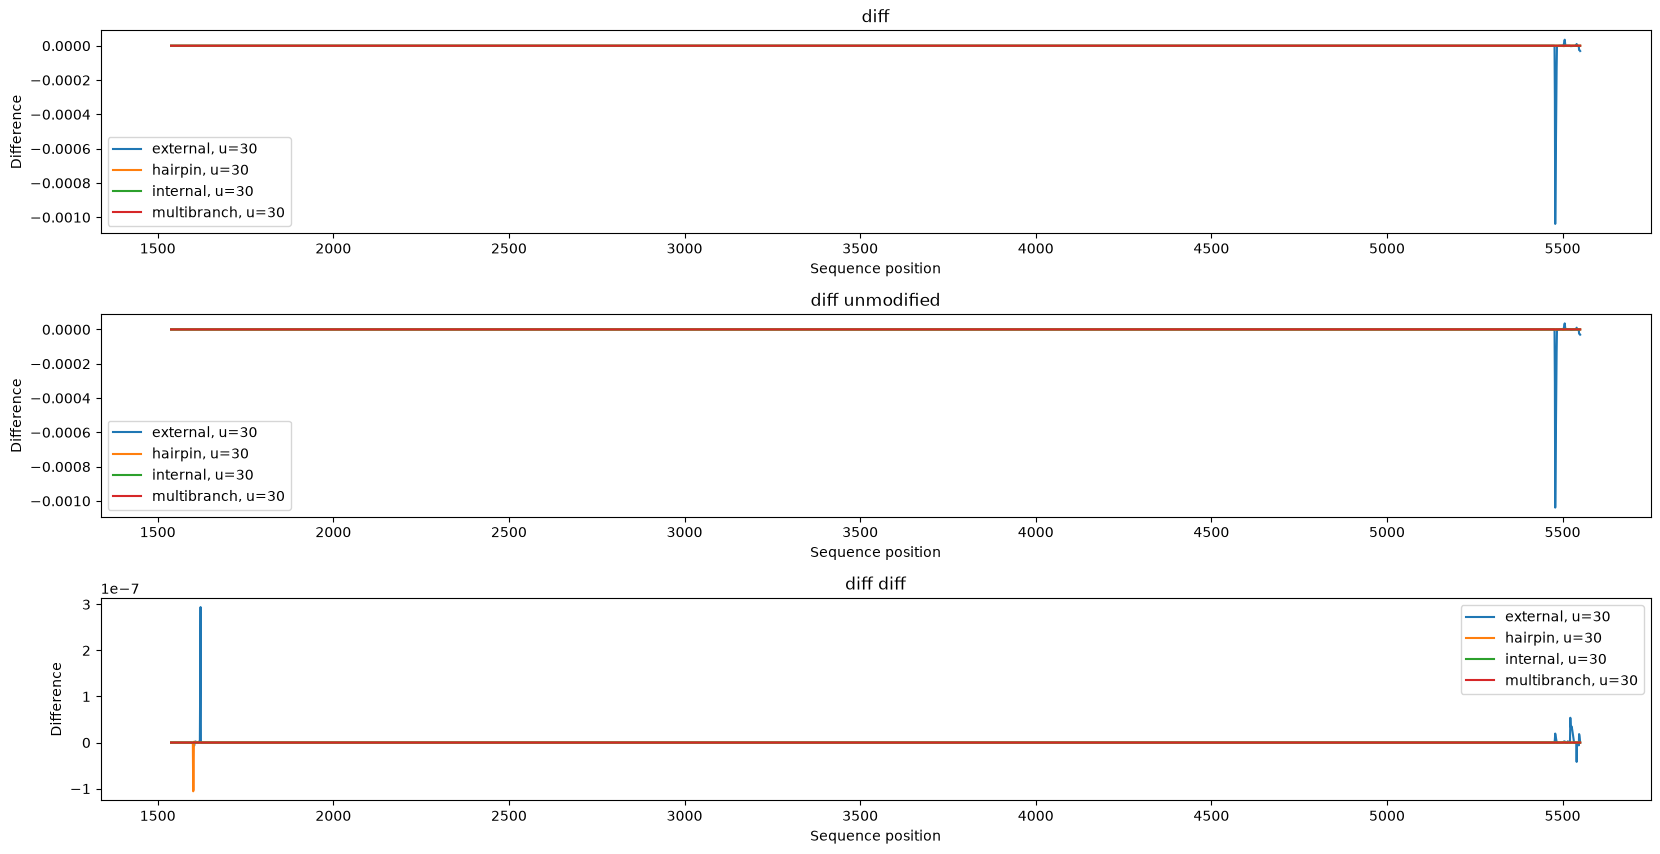

In [3]:
from mypython.algorithms import accessibility, looptypes
from mypython.plot import plot_accessibilities
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import matplotlib.pyplot as plt

fastaFile = get_files().get_assembled_region_fasta_files().get_exons_file()
fastaFile.open_or_recompute()

file = FASTA(fastaFile.get_possibly_gzip_path())
regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file())

footprints = [5, 30]
windowsize = 150
L = 100

slice_mult = 1

def map_entry(entry):
    region_name = entry.name[:entry.name.find(":")]
    sequence = str(entry.seq).upper().replace("T", "U")

    modifications = []
    
    if region_name in regions:
        modifications = regions[region_name].modifications

    return (region_name, sequence, modifications)

def filter_entry(entry):
    return len(entry[2]) != 0

def filter_length(entry):
    length = len(entry[1])
    return length > 8000 and length < 9000

def filter_start(entry):
    start = max(0, entry[2][0] - 2 * windowsize)
    return start != 0

def filter_end(entry):
    end = min(len(entry[1]), entry[2][len(entry[2]) - 1] + 2 * windowsize)
    return end != len(entry[1])

modified_regions =  filter(filter_end, filter(filter_start, filter(filter_length, filter(filter_entry, map(map_entry, file)))))

for _ in range(0):
    next(modified_regions)

for region_name, sequence, modifications in modified_regions:
    print(region_name)
    print(len(sequence))

    modifications = [x + 1 for x in modifications]
    modifications.sort()
    
    print(modifications)

    start = max(0, modifications[0] - int(windowsize * slice_mult))
    #start = 0
    end = min(len(sequence), modifications[len(modifications) - 1] + int(slice_mult * windowsize))
    #end = len(sequence)
    
    sequence_slice = sequence[start:end]
    modifications_slice = [x - start for x in modifications]
    print(start)
    print(end)
    data_slice_unmod = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L)
    data_slice = accessibility(sequence_slice, footprints, windowsize = windowsize, L = L, m6A_sites = modifications_slice)

    plot_accessibilities(sequence_slice, footprints, looptypes, start, end, data_slice, data_slice_unmod, modifications_slice)

    data_unmod = accessibility(sequence, footprints, windowsize = windowsize, L = L)
    data = accessibility(sequence, footprints, windowsize = windowsize, L = L, m6A_sites = modifications)
    
    plot_accessibilities(sequence, footprints, looptypes, 0, len(sequence), data, data_unmod, modifications)

    diff_data_unmod = {}
    diff_data = {}
    diff_data_diff = {}

    for footprint in footprints:
        diff_fp_data_unmod = {}
        diff_fp_data = {}
        diff_fp_data_diff = {}
        for looptype in looptypes:
            diff_fp_data_unmod[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            diff_fp_data_diff[looptype] = [0.0 for x in data_slice[footprint][looptype]]
            
            for i in range(len(data_slice[footprint][looptype])):
                value = data[footprint][looptype][i + start]
                value_unmod = data_unmod[footprint][looptype][i + start]

                value_slice = data_slice[footprint][looptype][i]
                value_slice_unmod = data_slice_unmod[footprint][looptype][i]

                diff = value_unmod - value
                diff_slice = value_slice_unmod - value_slice
                
                diff_value = value - value_slice
                diff_value_unmod = value_unmod - value_slice_unmod

                diff_diff = diff - diff_slice

                diff_fp_data_unmod[looptype][i] = diff_value_unmod
                diff_fp_data[looptype][i] = diff_value
                diff_fp_data_diff[looptype][i] = diff_diff

        diff_data[footprint] = diff_fp_data
        diff_data_unmod[footprint] = diff_fp_data_unmod
        diff_data_diff[footprint] = diff_fp_data_diff

    
    for footprint in footprints:
        fig, axs = plt.subplots(3, sharey = False, figsize = (20, 10))
        for k, v in diff_data[footprint].items():
            axs[0].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[0].set_title("diff")
        axs[0].set_xlabel("Sequence position")
        axs[0].set_ylabel("Difference")
        axs[0].legend()
        for k, v in diff_data_unmod[footprint].items():
            axs[1].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[1].set_title("diff unmodified")
        axs[1].set_xlabel("Sequence position")
        axs[1].set_ylabel("Difference")
        axs[1].legend()
        for k, v in diff_data_diff[footprint].items():
            axs[2].plot([i + start for i in range(len(sequence_slice) + 1 - footprint + 1)], v, label = "{}, u={:d}".format(looptypes[k], footprint))
        axs[2].set_title("diff diff")
        axs[2].set_xlabel("Sequence position")
        axs[2].set_ylabel("Difference")
        axs[2].legend()

        fig.subplots_adjust(hspace=0.4)
        fig.show()
    break

Warum keine transcript annotations?

Warum 2 * windowsize?

Split cds with exons/introns in between?

In [10]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
import numpy as np
from collections import defaultdict

window_sizes = [100, 150, 200, 250, 300]
window_multipliers = [1, 2]

def get_start(modification, window_size, window_multiplier):
    return modification - int(window_size * window_multiplier)

def get_end(modification, window_size, window_multiplier):
    return modification + int(window_size * window_multiplier)

savings = defaultdict(dict)

for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    savings[key] = defaultdict(dict)
    
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())

    for window_size in window_sizes:
        savings[key][window_size] = defaultdict(dict)
        
        for window_multiplier in window_multipliers:
            savings[key][window_size][window_multiplier] = defaultdict(list)
    
    for entry in fasta_file:
        region_name = entry.name[:entry.name.find(":")]

        if not region_name in regions or len(regions[region_name].modifications) == 0:
            continue
        
        sequence = str(entry.seq)

        sequence_length = len(sequence)

        modifications = regions[region_name].modifications
        modifications.sort()

        for window_size in window_sizes:
            for window_multiplier in window_multipliers:
                total_saving = 0
                savings[key][window_size][window_multiplier]["length"].append(sequence_length)

                first_start = max(0, get_start(modifications[0], window_size, window_multiplier))
                last_end = min(len(sequence), get_end(modifications[-1], window_size, window_multiplier))

                start_saving = first_start
                savings[key][window_size][window_multiplier]["start"].append(start_saving)
                total_saving += start_saving

                end_saving = len(sequence) - last_end
                savings[key][window_size][window_multiplier]["end"].append(end_saving)
                total_saving += end_saving

                inner_saving = 0
                for i in range(len(modifications) - 1):
                    current_end = get_end(modifications[i], window_size, window_multiplier)
                    next_start = get_start(modifications[i + 1], window_size, window_multiplier)

                    if next_start <= current_end:
                        continue

                    saving = next_start - current_end

                    inner_saving += saving
                
                savings[key][window_size][window_multiplier]["inner"].append(inner_saving)

                total_saving += inner_saving
                
                savings[key][window_size][window_multiplier]["total"].append(total_saving)
                
print("done")

done


In [ ]:
for key, key_savings in savings.items():
    for window_size, kw_savings in key_savings.items():
        fig, axs = plt.subplots(len(window_multipliers), 4, figsize=(15, 3))

        for i in range(len(window_multipliers)):
            window_multiplier = window_multipliers[i]

            kwm_savings = kw_savings[window_multiplier]

            axs[i][0].scatter(kwm_savings["length"], kwm_savings["start"])
            axs[i][0].set_title("Saving " + key + " " + str(window_size) + " " + str(window_multiplier) + " start")
            axs[i][1].scatter(kwm_savings["length"], kwm_savings["end"])
            axs[i][1].set_title("Saving " + key + " " + str(window_size) + " " + str(window_multiplier) + " end")
            axs[i][2].scatter(kwm_savings["length"], kwm_savings["inner"])
            axs[i][2].set_title("Saving " + key + " " + str(window_size) + " " + str(window_multiplier) + " inner")
            axs[i][3].scatter(kwm_savings["length"], kwm_savings["total"])
            axs[i][3].set_title("Saving " + key + " " + str(window_size) + " " + str(window_multiplier) + " total")
        
        fig.show()

In [25]:
from fasta import FASTA
from src.util import load_region_modifications
from src.files.files import get_files
from mypython.algorithms import accessibility, looptypes
import numpy as np
from collections import defaultdict
from pathlib import Path
import gzip
import csv

window_sizes = [150, 200, 350, 300]
footprints = [5, 10, 15, 20, 25, 30]
L = 100

def get_naive_start(modification, window_size):
    return modification - window_size

def get_naive_end(modification, window_size):
    return modification + window_size

def get_interval_from_modification(modification, window_size, sequence_length):
    interval_start = max(0, get_naive_start(modification, window_size))
    interval_end = min(sequence_length, get_naive_end(modification, window_size))

    return (interval_start, interval_end, [modification])

def are_intervals_overlapping(a, b):
    return a[1] >= b[0]

def combine_intervals(a, b):
    return (a[0], b[1], a[2] + b[2])

done_keys = []


for key, file in get_files().get_assembled_region_fasta_files().get_files_dict().items():
    if key in done_keys:
        continue
        
    print(key)
    regions = load_region_modifications(get_files().get_assembled_region_local_intersects_assembled_files().get_files_dict()[key])
    
    file.open_or_recompute()
    fasta_file = FASTA(file.get_possibly_gzip_path())
    continue
    Path("data/accessibilities/").mkdir(parents=True, exist_ok=True)
    
    with gzip.open("data/accessibilities/accessibilities_" + key + ".gz", "wt") as outputFile:
        outputCSV = csv.writer(outputFile, delimiter="\t")
    
        for i, entry in enumerate(fasta_file):
            if i % 100 == 0:
                print(i)
            
            region_name = entry.name[:entry.name.find(":")]
    
            if not region_name in regions or len(regions[region_name].modifications) == 0:
                continue
            
            sequence = str(entry.seq).upper().replace("T", "U")
    
            sequence_length = len(sequence)
    
            modifications = regions[region_name].modifications
            modifications.sort()
    
            for window_size in window_sizes:
                intervals = []
    
                for modification in modifications:
                    intervals.append(get_interval_from_modification(modification, window_size, sequence_length))
    
                i = 0
    
                while i < len(intervals) - 1:
                    interval_a = intervals[i]
                    interval_b = intervals[i + 1]
                    
                    if are_intervals_overlapping(interval_a, interval_b):
                        combined_interval = combine_intervals(interval_a, interval_b)
                        intervals[i] = combined_interval
                        intervals.pop(i + 1)
                        continue
                    
                    i += 1
    
                for start, end, interval_modifications in intervals:
                    interval_sequence = sequence[start:end]

                    interval_modifications_str = [str(x) for x in interval_modifications]

                    adjusted_interval_modifications = [x - start for x in interval_modifications]

                    accessibilities_unmod = accessibility(interval_sequence, footprints, windowsize = window_size, L = L)
                    accessibilities = accessibility(interval_sequence, footprints, windowsize = window_size, L = L, m6A_sites = adjusted_interval_modifications)

                    for footprint, fp_accessibilities_unmod in accessibilities_unmod.items():
                        for feature, fp_f_accessibilities_unmod in fp_accessibilities_unmod.items():
                            fp_f_accessibilities_mod = accessibilities[footprint][feature]

                            fp_f_accessibilities_mod_str = [str(x) for x in fp_f_accessibilities_mod]
                            fp_f_accessibilities_unmod_str = [str(x) for x in fp_f_accessibilities_unmod]
                            
                            outputCSV.writerow([region_name, str(window_size), str(start), str(end), ",".join(interval_modifications_str), str(footprint), feature, ",".join(fp_f_accessibilities_mod_str), ",".join(fp_f_accessibilities_unmod_str)])

    print(key + " done")
print("done")

3utr
Converting intersects in data/regions_intersect/region_3utr_intersect.bed.gz into local intersects in data/regions_intersect_local/region_3utr_intersect_local.gz
Converting intersects in data/regions_intersect/region_3utr_intersect.bed.gz into local intersects in data/regions_intersect_local/region_3utr_intersect_local.gz done
Assembling local Intersects for data/regions_intersect_local/region_3utr_intersect_local.gz into data/regions_intersect_local_assembled/region_3utr_intersect_local_assembled.gz
Assembling local Intersects for data/regions_intersect_local/region_3utr_intersect_local.gz into data/regions_intersect_local_assembled/region_3utr_intersect_local_assembled.gz done
Getting fasta for data/regions/region_3utr.bed into data/regions_fasta/region_3utr.fna.gz
Getting fasta for data/regions/region_3utr.bed into data/regions_fasta/region_3utr.fna.gz done
5utr
Converting intersects in data/regions_intersect/region_5utr_intersect.bed.gz into local intersects in data/regions_in

In [48]:
import gzip
import csv

with gzip.open("data/accessibilities/accessibilities_3utr.gz", "rt") as gzipFile:
    file = csv.reader(gzipFile, delimiter = "\t")

    first_line = None
    extremes = {}
    
    for line in file:
        if first_line == None:
            first_line = line
            continue

        if first_line[0] != line[0]:
            raise Exception("Different region names")

        if first_line[1] != line[1]:
            raise Exception("Different window size")

        if first_line[2] != line[2]:
            raise Exception("Different start")

        if first_line[3] != line[3]:
            raise Exception("Different end")

        if first_line[4] != line[4]:
            raise Exception("Different modifications")

        if first_line[5] != line[5]:
            raise Exception("Different footprint")

        if first_line[6] != line[6]:
            raise Exception("Different feature")

        if first_line[7] == line[7]:
            raise Exception("Same modification state")

        first_line_data = list(map(float, first_line[8].split(",")))
        line_data = list(map(float, line[8].split(",")))
        
        if len(first_line_data) != len(line_data):
            raise Exception("Different result size")

        region_name = line[0]
        window_size = line[1]
        start = line[2]
        end = line[3]

        if int(end) - int(start) > 5000:
            first_line = None
            continue
        
        modifications = list(map(int, line[4].split(",")))
        
        footprint = line[5]
        feature = line[6]
        
        mod_data = None
        unmod_data = None

        if first_line[7] == "mod":
            mod_data = first_line_data
            unmod_data = line_data
        else:
            mod_data = line_data
            unmod_data = first_line_data

        diff_data = [v for v in map(lambda pair: pair[1] - pair[0], zip(mod_data, unmod_data))]

        max_diff = max(diff_data)
        min_diff = min(diff_data)

        if (window_size, footprint, feature) in extremes:
            existing_extremes = extremes[(window_size, footprint, feature)]

            existing_max = existing_extremes["max"]
            existing_min = existing_extremes["min"]

            if max_diff > existing_max[0]:
                extremes[(window_size, footprint, feature)]["max"] = (max_diff, window_size, footprint, feature, region_name, start, end, modifications, unmod_data, mod_data, diff_data)

            if min_diff < existing_min[0]:
                extremes[(window_size, footprint, feature)]["min"] = (min_diff, window_size, footprint, feature, region_name, start, end, modifications, unmod_data, mod_data, diff_data)
        else:
            extremes[(window_size, footprint, feature)] = {}
            extremes[(window_size, footprint, feature)]["max"] = (max_diff, window_size, footprint, feature, region_name, start, end, modifications, unmod_data, mod_data, diff_data)
            extremes[(window_size, footprint, feature)]["min"] = (min_diff, window_size, footprint, feature, region_name, start, end, modifications, unmod_data, mod_data, diff_data)

        first_line = None
print("done")

done


In [49]:
import gzip
import csv

with gzip.open("data/extremes/extremes_3utr.gz", "wt") as gzipFile:
    file = csv.writer(gzipFile, delimiter = "\t")

    for specification, min_max in extremes.items():
        for key, data in min_max.items():
            print(key, data[0], "window", data[1], "footprint", data[2], "feature", data[3], "region", data[4], "start", data[5], "end", data[6])

            modifications = data[7]
            unmod_data = data[8]
            mod_data = data[9]
            diff_data = data[10]

            modifications_str = ",".join([str(v) for v in modifications])
            unmod_str = ",".join([str(v) for v in unmod_data])
            mod_str = ",".join([str(v) for v in mod_data])
            diff_str = ",".join([str(v) for v in diff_data])
            
            file.writerow([key, data[0], data[1], data[2], data[3], data[4], data[5], data[6], modifications_str, unmod_str, mod_str, diff_str])

print("done")

max 0.22065712856590558 window 150 footprint 5 feature 1 region NM_001363275.2_3utr start 0 end 531
min -0.1794941358368408 window 150 footprint 5 feature 1 region XM_017013381.3_3utr start 0 end 1919
max 0.28175452236749393 window 150 footprint 5 feature 2 region XM_047421769.1_3utr start 4725 end 6031
min -0.4590947249238745 window 150 footprint 5 feature 2 region NM_018310.4_3utr start 0 end 1198
max 0.19833423851249005 window 150 footprint 5 feature 4 region NM_025151.5_3utr start 797 end 4056
min -0.1822284475992893 window 150 footprint 5 feature 4 region XM_047422135.1_3utr start 60 end 937
max 0.14373960976572736 window 150 footprint 5 feature 8 region NM_001363010.1_3utr start 0 end 2268
min -0.10409211396391896 window 150 footprint 5 feature 8 region NM_001286702.2_3utr start 0 end 1939
max 0.12316945890738021 window 150 footprint 10 feature 1 region NM_001204864.2_3utr start 0 end 995
min -0.1581753129170425 window 150 footprint 10 feature 1 region XM_017013381.3_3utr start 0

In [50]:
import gzip
import csv

global_min = None
global_max = None

def print_line(line):
    print(line[0], line[1], line[2], line[3], line[4], line[5], line[6], line[7], list(map(int, line[8].split(","))))

with gzip.open("data/extremes/extremes_3utr.gz", "rt") as gzipFile:
    file = csv.reader(gzipFile, delimiter = "\t")

    global_min = None
    global_max = None
    
    for line in file:
        if global_min == None or line[1] < global_min[1]:
            global_min = line

        if global_max == None or line[1] > global_max[1]:
            global_max = line

    print_line(global_min)
    print_line(global_max)
                

min -0.00028063894951080103 300 30 4 NM_025151.5_3utr 0 4206 [18, 68, 119, 171, 425, 526, 544, 569, 616, 634, 640, 947, 969, 1092, 1115, 1212, 1285, 1320, 1337, 1364, 1376, 1383, 1395, 1411, 1437, 1464, 1544, 1599, 1630, 1680, 1693, 1786, 1958, 1974, 2144, 2196, 2224, 2230, 2409, 2444, 2493, 2527, 2561, 2615, 2704, 2739, 2773, 2829, 2839, 2846, 2943, 2959, 3020, 3051, 3081, 3196, 3229, 3400, 3410, 3487, 3566, 3656, 3705, 3728, 3786, 3818, 3865, 3906]
max 0.3587405694576928 350 5 2 XM_011516968.3_3utr 0 4694 [2, 43, 48, 63, 103, 110, 169, 182, 189, 201, 254, 287, 299, 314, 344, 357, 388, 419, 426, 452, 603, 672, 717, 758, 920, 982, 1010, 1027, 1062, 1202, 1218, 1424, 1446, 1496, 1550, 1865, 2055, 2171, 2352, 2660, 2945, 2994, 3052, 3091, 3171, 3292, 3473, 3517, 3614, 3835, 4016, 4041, 4110, 4147, 4231, 4238, 4256, 4338, 4344]


In [55]:
import gzip
import csv
from fasta import FASTA
from src.files.files import get_files

get_files().get_assembled_region_fasta_files().get_3utr_file().open_or_recompute()

file = FASTA("data/regions_fasta/region_3utr.fna.gz")

for entry in file:
    region_name = entry.name[:entry.name.find(":")]

    if region_name == global_max[5]:
        max_seq = str(entry.seq).upper().replace("T", "U")
        max_start = int(global_max[6])
        max_end = int(global_max[7])
        max_seq_slice = max_seq[max_start:max_end]
        max_modifications = list(map(int, global_max[8].split(","))) 
        
        print("max", region_name)
        print(max_seq_slice)
        print()
        print(max_modifications)
        print()

        max_seq_modified = str(max_seq_slice)

        for max_modification in max_modifications:
            max_seq_modified = max_seq_modified[:max_modification] + "6" + max_seq_modified[max_modification + 1:]

        print(max_seq_modified)
        print()
    if region_name == global_min[5]:
        min_seq = str(entry.seq).upper().replace("T", "U")
        min_start = int(global_min[6])
        min_end = int(global_min[7])
        min_seq_slice = min_seq[min_start:min_end]
        min_modifications = list(map(int, global_min[8].split(","))) 
        
        print("min", region_name)
        print(min_seq_slice)
        print()
        print(min_modifications)
        print()
        
        min_seq_modified = str(min_seq_slice)

        for min_modification in min_modifications:
            min_seq_modified = min_seq_modified[:min_modification] + "6" + min_seq_modified[min_modification + 1:]

        print(min_seq_modified)
        print()
        

min NM_025151.5_3utr
UAAAUCAGCAGAAAAAAAACACCGAGACGUUUCUGUGACUUCACUUUCACCUGCUCCAGGGGUCAAGGACUUGCCUUGCCUGAUAACCAGCCAGCAGGCUCCGAAUCACCAUCUCCCUCACAUGUUAUCCGGCAAGAGUGAAUUCUACCAAUGGAAGCCAGGUUAAUGAUUACAAUUAAUCUUUUACUGUACAUUCCCAAGGCUUUAGUUUUAAAUGCCACUGUGCCUUUAACAAGGUUGUAAAUAUUUUAUGCCCACCAGAGAUGUGGUCAUAAGAUCUGAUCCUGAGCCAGAGAUUCAGAUGGCACAGGAAGUAUUCAUGUAUUUUAACACUGGGGUUUUCUUUCUUUCAUACUGAGAUUUUUUUUCAGUAUGUAUCCUCCAGCUCUUAAAGCUUACCUGAGAAAGCUUUAAAUGAGAAAAGGACCAUGCGAUUGGUGCUGUGUUACAUACACAUACUUUCUUGGCUUCUGAGUAGCUCAGGUGUGGCUUUUGGCUGCAGAUGUUAAAUUUUGAUACCAUGUAAACCUACCCAGCUUCUCAGACUUGGGUCUUGUUUUUUGAUGGGAACAGAGGUGUUUAGAGAAAGCCUCUGAGUAUGCCUUUCAGAUUUUGAACAAGCGGCCUUUUCUAAACAUCGACUUCUACUACUCUCUAGCCUUAAAAUACCUUCUGCUUAGAUCCAGGGCCCUUCUACUGGAGAUAGGAAAAGUAGAAUUCAGGAAUUAAAAGAAUUACUCUUUAUUCAAUUUGAGGAACUUGGUGAAAGCCCCUCCUCUUAUGACAGCCAGGUUCCUGCUGGCUAGACCAGCCUAUUCAGCGCUUUGCUAGGGGAUUGGGUGGUCCACGCACUCGCUAAUACAGUUCUCCAGGUGUGGAAUGAUGUCAAUACGAUUGCUUGGCCUUUUCCCCCUGUGCCUUUGCUCGGUGCUCUGGUUUCCUCAGCAACACUCCUUGUAAGGGGCAGAGACAGGGUCCA

In [9]:
import gzip
import csv
import re
from src.files.files import get_files

snoRegions = {}

with get_files().get_renamed_files().get_annotations_file().open_or_recompute() as gzipFile:
    csvFile = csv.reader(gzipFile, delimiter="\t")

    for line in csvFile:
        if not re.search("snoRNA", line[8]):
            continue

        meta = line[8].split(";")

        transcript_id = None

        for metaEntry in meta:
            if not re.search("transcript_id", metaEntry):
                continue

            transcript_id = metaEntry.strip().split(" ")[1][1:-1]
            
            if transcript_id == "":
                continue

            snoRegions[transcript_id] = (transcript_id, line[3], line[4], line[6])

print(snoRegions)
        

{'XR_007061201.1': ('XR_007061201.1', '5128279', '5128412', '-'), 'XR_007061200.1': ('XR_007061200.1', '8961575', '8961708', '+'), 'NR_145772.1': ('NR_145772.1', '9058539', '9058630', '-'), 'XR_007061216.1': ('XR_007061216.1', '9866907', '9867010', '-'), 'XR_007061213.1': ('XR_007061213.1', '9931720', '9931823', '-'), 'NR_132779.1': ('NR_132779.1', '11705362', '11705558', '+'), 'XR_007061198.1': ('XR_007061198.1', '18979619', '18979772', '+'), 'NR_145737.1': ('NR_145737.1', '20614829', '20614926', '-'), 'XR_007061221.1': ('XR_007061221.1', '22032350', '22032452', '+'), 'NR_003041.1': ('NR_003041.1', '33513475', '33513578', '+'), 'NR_145988.1': ('NR_145988.1', '39018616', '39018685', '-'), 'NR_145746.1': ('NR_145746.1', '41426655', '41426727', '+'), 'XR_007061209.1': ('XR_007061209.1', '42043504', '42043575', '-'), 'XR_007061223.1': ('XR_007061223.1', '42225633', '42225734', '-'), 'XR_007061224.1': ('XR_007061224.1', '43378298', '43378510', '+'), 'XR_007061203.1': ('XR_007061203.1', '51

In [11]:
import gzip
import csv
import re
from src.files.files import get_files

file_keys = ["exons", "introns", "5utr", "3utr", "cds"]
keys = ["exon", "intron", "5utr", "3utr", "cds"]

modified_sno_transcripts = {} 

for file_key, key in zip(file_keys, keys):
    print(key)

    with get_files().get_assembled_region_intersects_files().get_files_dict()[file_key].open_or_recompute() as file:
        csvFile = csv.reader(file, delimiter="\t")
    
        for line in csvFile:
            if not line[3][:-len("_" + str(key))] in snoRegions:
                continue

            modified_sno_transcripts[line[3]] = line
            print(line)

exon
['chr8', '33513542', '33513543', 'NR_003041.1_exon', '0', '+', '33513474', '33513578', '0', '1', '104,', '0,']
['chr8', '66922479', '66922480', 'NR_002598.1_exon', '0', '-', '66922473', '66922549', '0', '1', '76,', '0,']
intron
Computing Intersects for data/regions/region_introns.bed into data/regions_intersect/region_introns_intersect.bed.gz
Computing Intersects for data/regions/region_introns.bed into data/regions_intersect/region_introns_intersect.bed.gz done
5utr
Computing Intersects for data/regions/region_5utr.bed into data/regions_intersect/region_5utr_intersect.bed.gz
Computing Intersects for data/regions/region_5utr.bed into data/regions_intersect/region_5utr_intersect.bed.gz done
3utr
Computing Intersects for data/regions/region_3utr.bed into data/regions_intersect/region_3utr_intersect.bed.gz
Computing Intersects for data/regions/region_3utr.bed into data/regions_intersect/region_3utr_intersect.bed.gz done
cds
Computing Intersects for data/regions/region_cds.bed into da

In [13]:
from src.files.files import get_files
import csv

local_modified_sno_transcripts = {}

with get_files().get_assembled_region_local_intersects_assembled_files().get_exons_file().open_or_recompute() as file:
    csvFile = csv.reader(file, delimiter="\t")

    for line in csvFile:
        if not line[0] in modified_sno_transcripts:
            continue

        local_modified_sno_transcripts[line[0]] = line
        print(line)

Assembling local Intersects for data/regions_intersect_local/region_exons_intersect_local.gz into data/regions_intersect_local_assembled/region_exons_intersect_local_assembled.gz
Assembling local Intersects for data/regions_intersect_local/region_exons_intersect_local.gz into data/regions_intersect_local_assembled/region_exons_intersect_local_assembled.gz done
['NR_003041.1_exon', '68']
['NR_002598.1_exon', '69']


In [22]:
from src.files.files import get_files
import csv
from fasta import FASTA

get_files().get_assembled_region_fasta_files().get_exons_file().open_or_recompute()

file = FASTA(get_files().get_assembled_region_fasta_files().get_exons_file().get_possibly_gzip_path())

for entry in file:
    entry_name = entry.name[:entry.name.find(":")]

    if not entry_name in local_modified_sno_transcripts:
        continue

    entry_modifications = list(map(int, local_modified_sno_transcripts[entry_name][1].split(",")))
        
    print(entry_name)
    print(entry_modifications)
    print()

    entry_rna_sequence = str(entry.seq).upper().replace("T", "U")

    print(entry_rna_sequence)
    print()

    modified_entry_rna_sequence = entry_rna_sequence

    for modification in entry_modifications:
        modified_entry_rna_sequence = modified_entry_rna_sequence[:modification] + "6" + modified_entry_rna_sequence[modification + 1:]

    print(modified_entry_rna_sequence)
    print()

NR_003041.1_exon
[68]

AUCCUUUUGUAGUUCAUGAGCGUGAUGAUUGGGUGUUCAUACGCUUGUGUGAGAUGUGCCACCCUUGAACCUUGUUACGACGUGGGCACAUUACCCGUCUGACC

AUCCUUUUGUAGUUCAUGAGCGUGAUGAUUGGGUGUUCAUACGCUUGUGUGAGAUGUGCCACCCUUGA6CCUUGUUACGACGUGGGCACAUUACCCGUCUGACC

NR_002598.1_exon
[69]

ACAAUGAUGACUUAAAUUACUUUUUGCCGUUUACCCAGCUGAGGUUGUCUUUGAAGAAAUAAUUUUAAGACUGAGA

ACAAUGAUGACUUAAAUUACUUUUUGCCGUUUACCCAGCUGAGGUUGUCUUUGAAGAAAUAAUUUUAAG6CUGAGA



In [20]:
import gzip
import csv
import re
from fasta import FASTA
from src.files.files import get_files
from collections import defaultdict

# D = A, G, U
# R = A, G
# A = A
# C = C
# H = A, C, U

drach_options = ["UAACA", "UAACC", "UAACU", "UGACA", "UGACC", "UGACU"]
rrach_options = ["AAACA", "AAACC", "AAACU", "AGACA", "AGACC", "AGACU", "GAACA", "GAACC", "GAACU", "GGACA", "GGACC", "GGACU"]

neg_drach_options = [option[::-1] for option in drach_options]
neg_rrach_options = [option[::-1] for option in rrach_options]

get_files().get_renamed_files().get_genome_file().open_or_recompute()

file = FASTA(get_files().get_renamed_files().get_genome_file().get_possibly_gzip_path())

modification_positions = {}
neg_modification_positions = {}

with get_files().get_renamed_files().get_modifications_file().open_or_recompute() as modification_file:
    modification_csv_file = csv.reader(modification_file, delimiter="\t")

    for modification in modification_csv_file:
        if modification[5] == ".":
            continue

        if modification[5] == "+":
            modification_positions[int(modification[1])] = True
        else:
            neg_modification_positions[int(modification[1])] = True
        

drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }
rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }

neg_drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }
neg_rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int) }

modifications_in_drach = 0
modifications_in_rrach = 0
modifications_outside_motif = 0

neg_modifications_in_drach = 0
neg_modifications_in_rrach = 0
neg_modifications_outside_motif = 0

for entry in file:
    rna_seq = str(entry.seq).upper().replace("T", "U")

    for window_start in range(len(rna_seq) - 5):
        window = rna_seq[window_start:window_start+5]

        window_modification_position = window_start + 2
        
        if window in rrach_options:
            if window_modification_position in modification_positions:
                drach_stats["modified"][window] += 1
                rrach_stats["modified"][window] += 1
            else:
                drach_stats["unmodified"][window] += 1
                rrach_stats["unmodified"][window] += 1
                
        if window in drach_options:
            if window_modification_position in modification_positions:
                drach_stats["modified"][window] += 1
            else:
                drach_stats["unmodified"][window] += 1
                
        if window in neg_rrach_options:
            if window_modification_position in neg_modification_positions:
                neg_drach_stats["modified"][window] += 1
                neg_rrach_stats["modified"][window] += 1
            else:
                neg_drach_stats["unmodified"][window] += 1
                neg_rrach_stats["unmodified"][window] += 1
                
        if window in neg_drach_options:
            if window_modification_position in neg_modification_positions:
                neg_drach_stats["modified"][window] += 1
            else:
                neg_drach_stats["unmodified"][window] += 1

    for modification_position in modification_positions.keys():
        if modification_position < 2 or modification_position > len(rna_seq) - 3:
            modifications_outside_motif += 1
            continue
        
        modification_window = rna_seq[modification_position - 2:modification_position + 3]

        if modification_window in rrach_options:
            modifications_in_drach += 1
            modifications_in_rrach += 1
            continue
        if modification_window in drach_options:
            modifications_in_drach += 1
            continue
        
        modifications_outside_motif += 1
        
    for neg_modification_position in neg_modification_positions.keys():
        if neg_modification_position < 2 or neg_modification_position > len(rna_seq) - 3:
            neg_modifications_outside_motif += 1

        neg_modification_window = rna_seq[neg_modification_position - 2:neg_modification_position + 3]

        if neg_modification_window in neg_rrach_options:
            neg_modifications_in_drach += 1
            neg_modifications_in_rrach += 1
            continue
        if neg_modification_window in neg_drach_options:
            neg_modifications_in_drach += 1
            continue
        
        neg_modifications_outside_motif += 1

print("done")

done


In [27]:
drach_stats["total"] = defaultdict(int)
rrach_stats["total"] = defaultdict(int)

neg_drach_stats["total"] = defaultdict(int)
neg_rrach_stats["total"] = defaultdict(int)

total_drach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }
total_rrach_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }

total_total_stats = { "unmodified": defaultdict(int), "modified": defaultdict(int), "total": defaultdict(int) }

total_modifications = 0
total_neg_modifications = 0

total_modifications_in_drach = 0
total_modifications_in_rrach = 0
total_modifications_outside_motif = 0
total_total_modifications = 0

for key, stat in drach_stats["unmodified"].items():
    drach_stats["total"][key] = drach_stats["unmodified"][key] + drach_stats["modified"][key]

for key, stat in rrach_stats["unmodified"].items():
    rrach_stats["total"][key] = rrach_stats["unmodified"][key] + rrach_stats["modified"][key]

for key, stat in neg_drach_stats["unmodified"].items():
    neg_drach_stats["total"][key] = neg_drach_stats["unmodified"][key] + neg_drach_stats["modified"][key]

for key, stat in neg_rrach_stats["unmodified"].items():
    neg_rrach_stats["total"][key] = neg_rrach_stats["unmodified"][key] + neg_rrach_stats["modified"][key]

drach_stats["unmodified"]["total"] = sum(drach_stats["unmodified"].values())
drach_stats["modified"]["total"] = sum(drach_stats["modified"].values())
drach_stats["total"]["total"] = sum(drach_stats["total"].values())

rrach_stats["unmodified"]["total"] = sum(rrach_stats["unmodified"].values())
rrach_stats["modified"]["total"] = sum(rrach_stats["modified"].values())
rrach_stats["total"]["total"] = sum(rrach_stats["total"].values())

neg_drach_stats["unmodified"]["total"] = sum(neg_drach_stats["unmodified"].values())
neg_drach_stats["modified"]["total"] = sum(neg_drach_stats["modified"].values())
neg_drach_stats["total"]["total"] = sum(neg_drach_stats["total"].values())

neg_rrach_stats["unmodified"]["total"] = sum(neg_rrach_stats["unmodified"].values())
neg_rrach_stats["modified"]["total"] = sum(neg_rrach_stats["modified"].values())
neg_rrach_stats["total"]["total"] = sum(neg_rrach_stats["total"].values())

for key, stat in drach_stats["unmodified"].items():
    total_drach_stats["unmodified"][key] = drach_stats["unmodified"][key] + neg_drach_stats["unmodified"][key]

for key, stat in drach_stats["modified"].items():
    total_drach_stats["modified"][key] = drach_stats["modified"][key] + neg_drach_stats["modified"][key]

for key, stat in drach_stats["total"].items():
    total_drach_stats["total"][key] = drach_stats["total"][key] + neg_drach_stats["total"][key]

for key, stat in rrach_stats["unmodified"].items():
    total_rrach_stats["unmodified"][key] = rrach_stats["unmodified"][key] + neg_rrach_stats["unmodified"][key]

for key, stat in rrach_stats["modified"].items():
    total_rrach_stats["modified"][key] = rrach_stats["modified"][key] + neg_rrach_stats["modified"][key]

for key, stat in rrach_stats["total"].items():
    total_rrach_stats["total"][key] = rrach_stats["total"][key] + neg_rrach_stats["total"][key]

for key, stat in drach_stats["unmodified"].items():
    total_total_stats["unmodified"][key] = total_drach_stats["unmodified"][key] + total_rrach_stats["unmodified"][key]

for key, stat in drach_stats["modified"].items():
    total_total_stats["modified"][key] = total_drach_stats["modified"][key] + total_rrach_stats["modified"][key]

for key, stat in drach_stats["total"].items():
    total_total_stats["total"][key] = total_drach_stats["total"][key] + total_rrach_stats["total"][key]

total_modifications = modifications_in_drach + modifications_in_rrach
total_neg_modifications = neg_modifications_in_drach + neg_modifications_in_rrach

total_modifications_in_drach = modifications_in_drach + neg_modifications_in_drach
total_modifications_in_rrach = modifications_in_rrach + neg_modifications_in_rrach
total_modifications_outside_motif = modifications_outside_motif + neg_modifications_outside_motif

total_total_modifications = total_modifications_in_drach + total_total_modifications

print("done")


done


In [28]:
print("drach:", drach_stats)
print("rrach:", rrach_stats)
print("neg_drach:", neg_drach_stats)
print("neg_rrach:", neg_rrach_stats)

print("total_drach:", total_drach_stats)
print("total_rrach:", total_rrach_stats)
print("total_total:", total_total_stats)

drach: {'unmodified': defaultdict(<class 'int'>, {'UGACA': 173238, 'AAACA': 360764, 'AGACU': 159091, 'UAACA': 182578, 'AAACU': 265527, 'AGACC': 116167, 'UAACC': 84206, 'UGACU': 153147, 'GAACU': 147010, 'UGACC': 108424, 'GGACA': 128315, 'AAACC': 176404, 'AGACA': 228784, 'GAACA': 171059, 'GGACU': 102666, 'GAACC': 97522, 'UAACU': 149826, 'GGACC': 62193, 'total': 11467684}), 'modified': defaultdict(<class 'int'>, {'AAACC': 711, 'AGACA': 1005, 'GGACC': 802, 'AGACU': 754, 'GGACU': 797, 'AAACA': 1229, 'AAACU': 901, 'AGACC': 744, 'GAACU': 788, 'GGACA': 1022, 'UAACA': 211, 'UGACA': 291, 'GAACC': 574, 'UGACU': 134, 'UAACU': 63, 'GAACA': 959, 'UGACC': 22, 'UAACC': 10, 'total': 44068}), 'total': defaultdict(<class 'int'>, {'UGACA': 173529, 'AAACA': 361993, 'AGACU': 159845, 'UAACA': 182789, 'AAACU': 266428, 'AGACC': 116911, 'UAACC': 84216, 'UGACU': 153281, 'GAACU': 147798, 'UGACC': 108446, 'GGACA': 129337, 'AAACC': 177115, 'AGACA': 229789, 'GAACA': 172018, 'GGACU': 103463, 'GAACC': 98096, 'UAACU': 